<a href="https://colab.research.google.com/github/Vinutha-Reddy/Internship-Projects/blob/main/Project_03_ML_Classification_HR_Employee.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Project Title - HR Attrition Prediction (Classification)**

# **2. Problem Statement**
Employee attrition is a critical issue for organizations, leading to increased hiring costs,
productivity loss, and reduced employee morale.

In this project, the goal is to build a Machine Learning classification model that predicts
whether an employee will leave the company (Attrition: Yes/No) based on features such as:
- Age
- Salary
- Job Role
- Job Satisfaction
- Work Experience
- Overtime
- Work-Life Balance
- Department

Students are required to analyze the dataset, preprocess the data, perform feature engineering,
train multiple classification models, and evaluate their performance to identify the best model for
predicting employee attrition.

# **3. Project Objectives**
The objective of this task is to:
- Understand and explore the HR dataset
- Perform data preprocessing (missing values, duplicates, outliers)
- Conduct Exploratory Data Analysis (EDA)
- Apply encoding and feature scaling
- Train multiple classification algorithms
- Evaluate models using classification metrics
- Perform cross-validation and hyperparameter tuning
- Select the best-performing model

# **4. Tools and Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **5. Dataset Loading**

In [ ]:
data = pd.read_csv('HR-Employee-Attrition.csv')
data

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


# **6. Preliminary Data Exploration**

In [ ]:
# Dataset Shape
data.shape

(1470, 35)

There are **1470 rows** and **35 columns**

In [ ]:
# Head
data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
# Tail
data.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,...,1,80,0,6,3,4,4,3,1,2


In [ ]:
# Dataset Information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
# Data Types
data.dtypes

,0
Age,int64
Attrition,object
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EmployeeCount,int64
EmployeeNumber,int64


In [ ]:
# Statistical Summary
# Numeric Columns
num_data=data.select_dtypes(include=['int64'])
num_data

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1102,1,2,1,1,2,94,3,2,...,1,80,0,8,0,1,6,4,0,5
1,49,279,8,1,1,2,3,61,2,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1373,2,2,1,4,4,92,2,1,...,2,80,0,7,3,3,0,0,0,0
3,33,1392,3,4,1,5,4,56,3,1,...,3,80,0,8,3,3,8,7,3,0
4,27,591,2,1,1,7,1,40,3,1,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,884,23,2,1,2061,3,41,4,2,...,3,80,1,17,3,3,5,2,0,3
1466,39,613,6,1,1,2062,4,42,2,3,...,1,80,1,9,5,3,7,7,1,7
1467,27,155,4,3,1,2064,2,87,4,2,...,2,80,1,6,0,3,6,2,0,3
1468,49,1023,2,3,1,2065,4,63,2,2,...,4,80,0,17,3,2,9,6,0,8


In [ ]:
# Statistical report of Numerical data
data.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [ ]:
# Categorical Columns
cat_data=data.select_dtypes(include=['object'])
cat_data

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
0,Yes,Travel_Rarely,Sales,Life Sciences,Female,Sales Executive,Single,Y,Yes
1,No,Travel_Frequently,Research & Development,Life Sciences,Male,Research Scientist,Married,Y,No
2,Yes,Travel_Rarely,Research & Development,Other,Male,Laboratory Technician,Single,Y,Yes
3,No,Travel_Frequently,Research & Development,Life Sciences,Female,Research Scientist,Married,Y,Yes
4,No,Travel_Rarely,Research & Development,Medical,Male,Laboratory Technician,Married,Y,No
...,...,...,...,...,...,...,...,...,...
1465,No,Travel_Frequently,Research & Development,Medical,Male,Laboratory Technician,Married,Y,No
1466,No,Travel_Rarely,Research & Development,Medical,Male,Healthcare Representative,Married,Y,No
1467,No,Travel_Rarely,Research & Development,Life Sciences,Male,Manufacturing Director,Married,Y,Yes
1468,No,Travel_Frequently,Sales,Medical,Male,Sales Executive,Married,Y,No


In [ ]:
# Statistical report of Categorical data
data.describe(include='object')

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


In [ ]:
data.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [ ]:
# Unique Values
df = data.drop(['EmployeeNumber','EmployeeCount','Over18','StandardHours'], axis=1, errors='ignore')
for x in df:
    print(f"{x} --> {df[x].unique()}")
    print()

Age --> [41 49 37 33 27 32 59 30 38 36 35 29 31 34 28 22 53 24 21 42 44 46 39 43
 50 26 48 55 45 56 23 51 40 54 58 20 25 19 57 52 47 18 60]

Attrition --> ['Yes' 'No']

BusinessTravel --> ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']

DailyRate --> [1102  279 1373 1392  591 1005 1324 1358  216 1299  809  153  670 1346
  103 1389  334 1123 1219  371  673 1218  419  391  699 1282 1125  691
  477  705  924 1459  125  895  813 1273  869  890  852 1141  464 1240
 1357  994  721 1360 1065  408 1211 1229  626 1434 1488 1097 1443  515
  853 1142  655 1115  427  653  989 1435 1223  836 1195 1339  664  318
 1225 1328 1082  548  132  746  776  193  397  945 1214  111  573 1153
 1400  541  432  288  669  530  632 1334  638 1093 1217 1353  120  682
  489  807  827  871  665 1040 1420  240 1280  534 1456  658  142 1127
 1031 1189 1354 1467  922  394 1312  750  441  684  249  841  147  528
  594  470  957  542  802 1355 1150 1329  959 1033 1316  364  438  689
  201 1427  857  933 1181 1395  662 

In [ ]:
# Value Counts
for x in df:
    print(df[x].value_counts())
    print()

Age
35    78
34    77
36    69
31    69
29    68
32    61
30    60
38    58
33    58
40    57
37    50
28    48
27    48
42    46
39    42
45    41
41    40
26    39
44    33
46    33
43    32
50    30
25    26
24    26
49    24
47    24
55    22
48    19
51    19
53    19
54    18
52    18
22    16
56    14
58    14
23    14
21    13
20    11
59    10
19     9
18     8
60     5
57     4
Name: count, dtype: int64

Attrition
No     1233
Yes     237
Name: count, dtype: int64

BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

DailyRate
691     6
1082    5
329     5
530     5
408     5
       ..
1382    1
161     1
801     1
642     1
1154    1
Name: count, Length: 886, dtype: int64

Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

DistanceFromHome
2     211
1     208
10     86
9      85
3      84
7      84
8      80
5      65
4      64
6     

In [ ]:
data

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


# **7. Data Cleaning and Preparation**

**7.1 Duplicate Handling**

In [ ]:
data.duplicated().sum()

np.int64(0)

There are **no duplicate values** in the data.

**7.2 Missing Value Treatment**

In [ ]:
data.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


There are **no missing values** in the data.

# **8. Data Visualization and Analysis**

**8.1 Univariate Analysis**

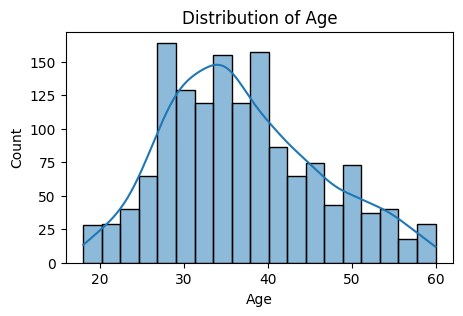

In [ ]:
# Distribution of Age
plt.figure(figsize=(5,3))
sns.histplot(data['Age'], kde=True)
plt.title("Distribution of Age")
plt.show()

**Insights**
* Most people fall in the **age group of around 25–40**, showing this is the dominant range
* The distribution is **slightly right-skewed**, as ages extend more towards higher values (40–60)
* There are **fewer younger individuals (below 25)** compared to middle-aged groups
* The count **gradually decreases after 40**, indicating fewer older participants


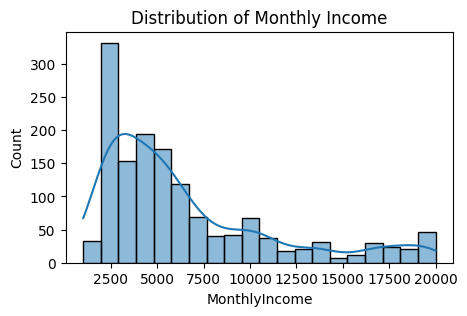

In [ ]:
# Distribution of Monthly Income
plt.figure(figsize=(5,3))
sns.histplot(data['MonthlyIncome'], kde=True)
plt.title("Distribution of Monthly Income")
plt.show()

**Insights**
* Most individuals have **income in the range of 2,000–6,000**, indicating a concentration in lower to mid income levels
* The distribution is **highly right-skewed**, with a long tail towards higher incomes
* There are **very few people earning above 10,000**, showing high-income groups are limited
* A noticeable **peak around 3,000–4,000** suggests this is the most common income range


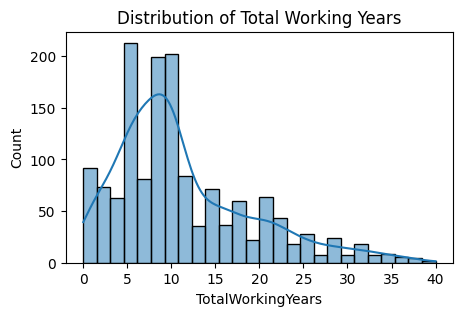

In [ ]:
# Distribution of Total Working Years
plt.figure(figsize=(5,3))
sns.histplot(data['TotalWorkingYears'], kde=True)
plt.title("Distribution of Total Working Years")
plt.show()

**Insights**
* Most employees have **around 5–12 years of experience**, showing a strong mid-experience group
* The distribution is **right-skewed**, with fewer people having very high experience (20+ years)
* There are **very few individuals with extremely low (0–2 years)** or very high (30+ years) experience
* The count **gradually decreases after 15 years**, indicating fewer highly experienced employees


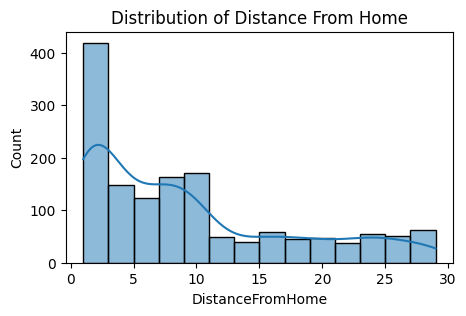

In [ ]:
# Distance From Home distributed
plt.figure(figsize=(5,3))
sns.histplot(data['DistanceFromHome'], kde=True)
plt.title("Distribution of Distance From Home")
plt.show()

**Insights**
* Most employees live **very close to work (1–5 units)**, showing a high concentration near the workplace
* The distribution is **right-skewed**, with distances extending up to around 30
* There is a **sharp drop after short distances**, indicating fewer people live far away
* A small number of employees are **spread across higher distance ranges (15–30)**, showing some long commuters


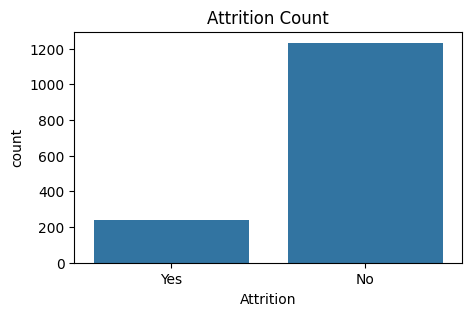

In [ ]:
# Count of employees by Attrition
plt.figure(figsize=(5,3))
sns.countplot(x='Attrition', data=data)
plt.title("Attrition Count")
plt.show()

**Insights**
* The number of employees with **No attrition is significantly higher** than those who left
* Only a **small portion of employees (Yes)** have left the organization
* This indicates a **low overall attrition rate** in the company
* There is a **clear imbalance between Yes and No**, showing most employees tend to stay


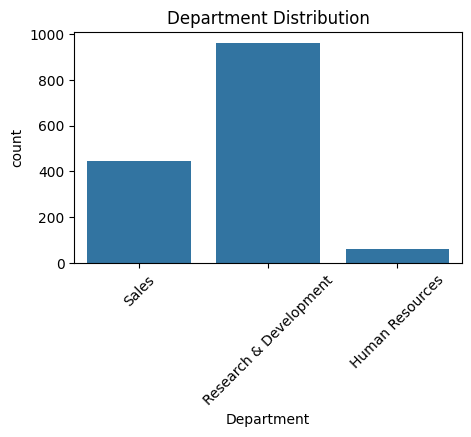

In [ ]:
# Distribution of employees across Departments
plt.figure(figsize=(5,3))
sns.countplot(x='Department', data=data)
plt.title("Department Distribution")
plt.xticks(rotation=45)
plt.show()

**Insights**
* Research & Development has the highest number of employees, showing it is the dominant department in the organization.
* Sales department has a moderate number of employees, significantly lower than R&D but much higher than HR.
* Human Resources has the least number of employees, indicating it is a smaller support function.
* There is a clear imbalance in employee distribution, with most employees concentrated in R&D compared to other departments.


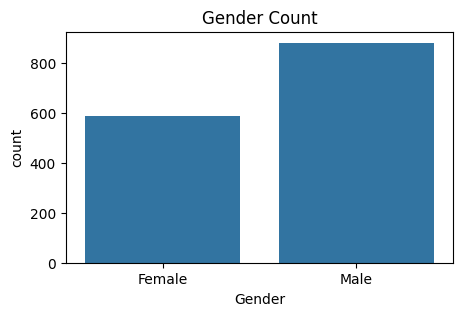

In [ ]:
# Count of employees by Gender
plt.figure(figsize=(5,3))
sns.countplot(x='Gender', data=data)
plt.title("Gender Count")
plt.show()

**Insights**
* The number of male employees is higher than female employees in the organization.
* Female employees make up a smaller portion of the workforce compared to males.
* There is a noticeable gender imbalance favoring male employees.
* The gap between male and female employees is significant, indicating less gender diversity.


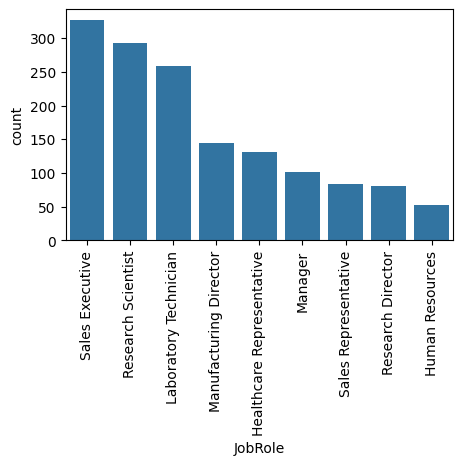

In [ ]:
# Distribution of Job Roles
plt.figure(figsize=(5,3))
sns.countplot(x='JobRole', data=data)
plt.xticks(rotation=90)
plt.show()

**Insights**
* Sales Executive role has the highest number of employees, making it the most common job role.
* Research Scientist and Laboratory Technician roles also have a high number of employees, showing strong focus on technical and research work.
* Manager, Sales Representative, and Research Director roles have comparatively fewer employees.
* Human Resources role has the least number of employees, indicating limited hiring in this area.

**8.2 Bivariate Analysis**

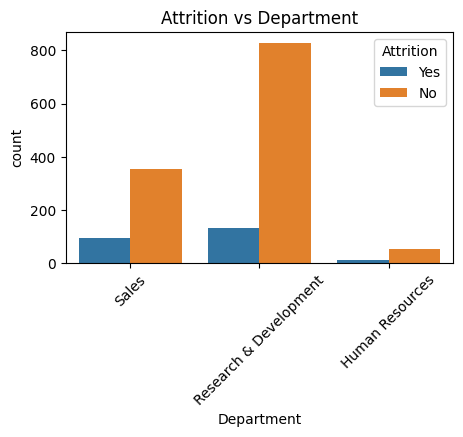

In [ ]:
# How does Attrition vary across Departments
plt.figure(figsize=(5,3))
sns.countplot(x='Department', hue='Attrition', data=data)
plt.title("Attrition vs Department")
plt.xticks(rotation=45)
plt.show()

**Insights**
* In all departments, the number of employees who did not leave is much higher than those who left.
* Research & Development has the highest number of employees as well as the highest attrition in absolute terms.
* Sales department shows a noticeable level of attrition compared to Human Resources.
* Human Resources has the lowest attrition, which may be due to its smaller workforce size.


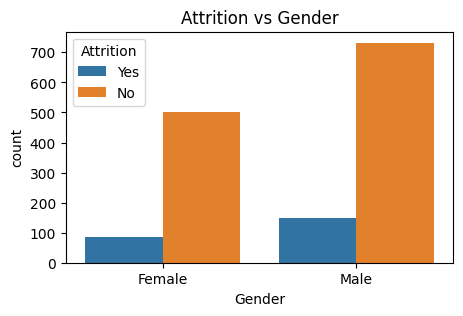

In [ ]:
# How does Attrition vary by Gender
plt.figure(figsize=(5,3))
sns.countplot(x='Gender', hue='Attrition', data=data)
plt.title("Attrition vs Gender")
plt.show()

**Insights**
* For both genders, the number of employees who stayed is much higher than those who left.
* Male employees have higher attrition in absolute numbers compared to female employees.
* Female employees show lower attrition, indicating relatively better retention.
* The overall trend suggests attrition is present in both genders but slightly more prominent among males.


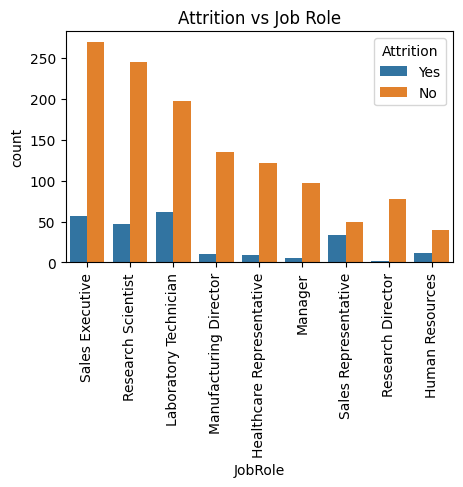

In [ ]:
# How does Attrition vary across Job Roles
plt.figure(figsize=(5,3))
sns.countplot(x='JobRole', hue='Attrition', data=data)
plt.title("Attrition vs Job Role")
plt.xticks(rotation=90)
plt.show()

**Insights**
* Most employees across all job roles are staying in the company, showing overall low attrition
* Sales Executive, Research Scientist, and Laboratory Technician roles have higher employee counts and also show comparatively higher attrition

* Laboratory Technician and Sales Executive roles experience noticeable employee turnover compared to other roles

* Manager and Research Director roles have very low attrition, indicating better employee retention in higher-level positions


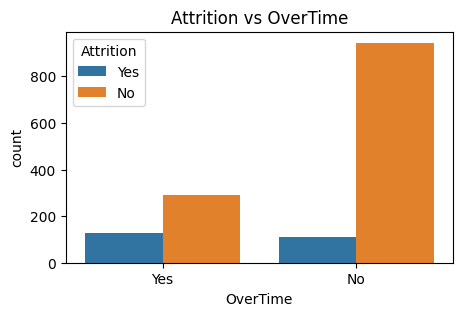

In [ ]:
# Does OverTime affect Attrition
plt.figure(figsize=(5,3))
sns.countplot(x='OverTime', hue='Attrition',data=data)
plt.title("Attrition vs OverTime")
plt.show()

**Insights**
* Employees who work overtime show higher attrition compared to those who do not

* A large number of employees who do not work overtime are staying in the company

* The gap between staying and leaving is much smaller for employees who work overtime, indicating higher turnover risk

* Employees without overtime have better retention, suggesting work-life balance may influence attrition


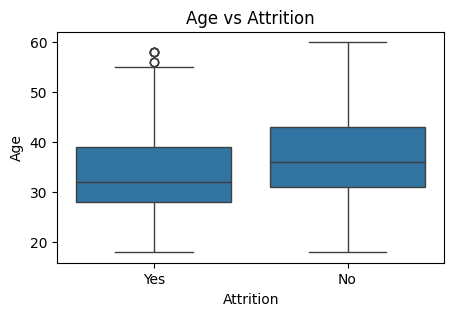

In [ ]:
# How does Age vary with Attrition
plt.figure(figsize=(5,3))
sns.boxplot(x='Attrition', y='Age', data=data)
plt.title("Age vs Attrition")
plt.show()

**Insights**
* Employees who left the company tend to be younger compared to those who stayed

* The median age of employees who stayed is higher, indicating older employees are more likely to remain

* There is a wider age spread among employees who stayed, showing more diversity in age group

* A few older employees also left the company, but most attrition is concentrated in the younger age group


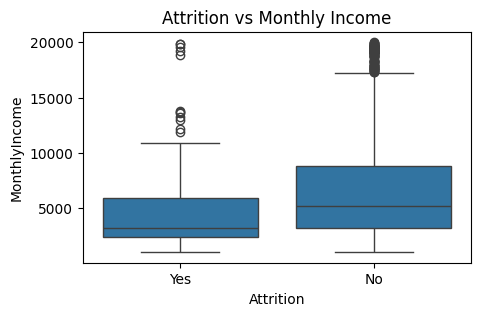

In [ ]:
# How does Monthly Income vary with Attrition
plt.figure(figsize=(5,3))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=data)
plt.title("Attrition vs Monthly Income")
plt.show()

**Insights**
* Employees who left the company generally have lower monthly income compared to those who stayed

* The median income is higher for employees who stayed, indicating better retention among higher-paid employees

* There is a wider income range among employees who stayed, including many high-income individuals

* A few high-income employees also left, but most attrition is concentrated among lower-income groups


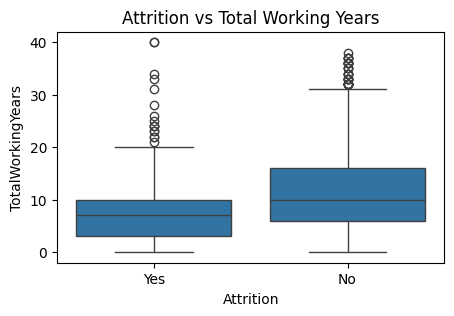

In [ ]:
# How does Total Working Years relate to Attrition
plt.figure(figsize=(5,3))
sns.boxplot(x='Attrition', y='TotalWorkingYears', data=df)
plt.title("Attrition vs Total Working Years")
plt.show()

**Insights**
* Employees who left the company generally have fewer total working years compared to those who stayed

* The median working experience is higher for employees who stayed, indicating experienced employees are more likely to remain

* Employees who stayed show a wider range of experience, including many with high years of service

* Some highly experienced employees also left, but most attrition is concentrated among less experienced employees


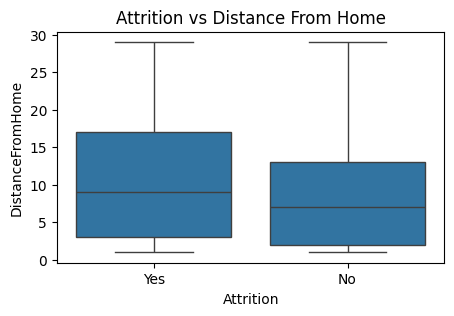

In [ ]:
# How does Distance From Home relate to Attrition
plt.figure(figsize=(5,3))
sns.boxplot(x='Attrition', y='DistanceFromHome', data=data)
plt.title("Attrition vs Distance From Home")
plt.show()

**Insights**
* Employees who left the company tend to have a slightly higher median distance from home compared to those who stayed

* The attrition group shows a wider spread in distance, indicating more variability among employees who left

* There is a significant overlap between both groups, suggesting distance from home alone is not a strong factor in predicting attrition

* Employees with very high commuting distances are present in both groups, indicating long distance does not always result in attrition


**8.3 Multivariate Analysis**

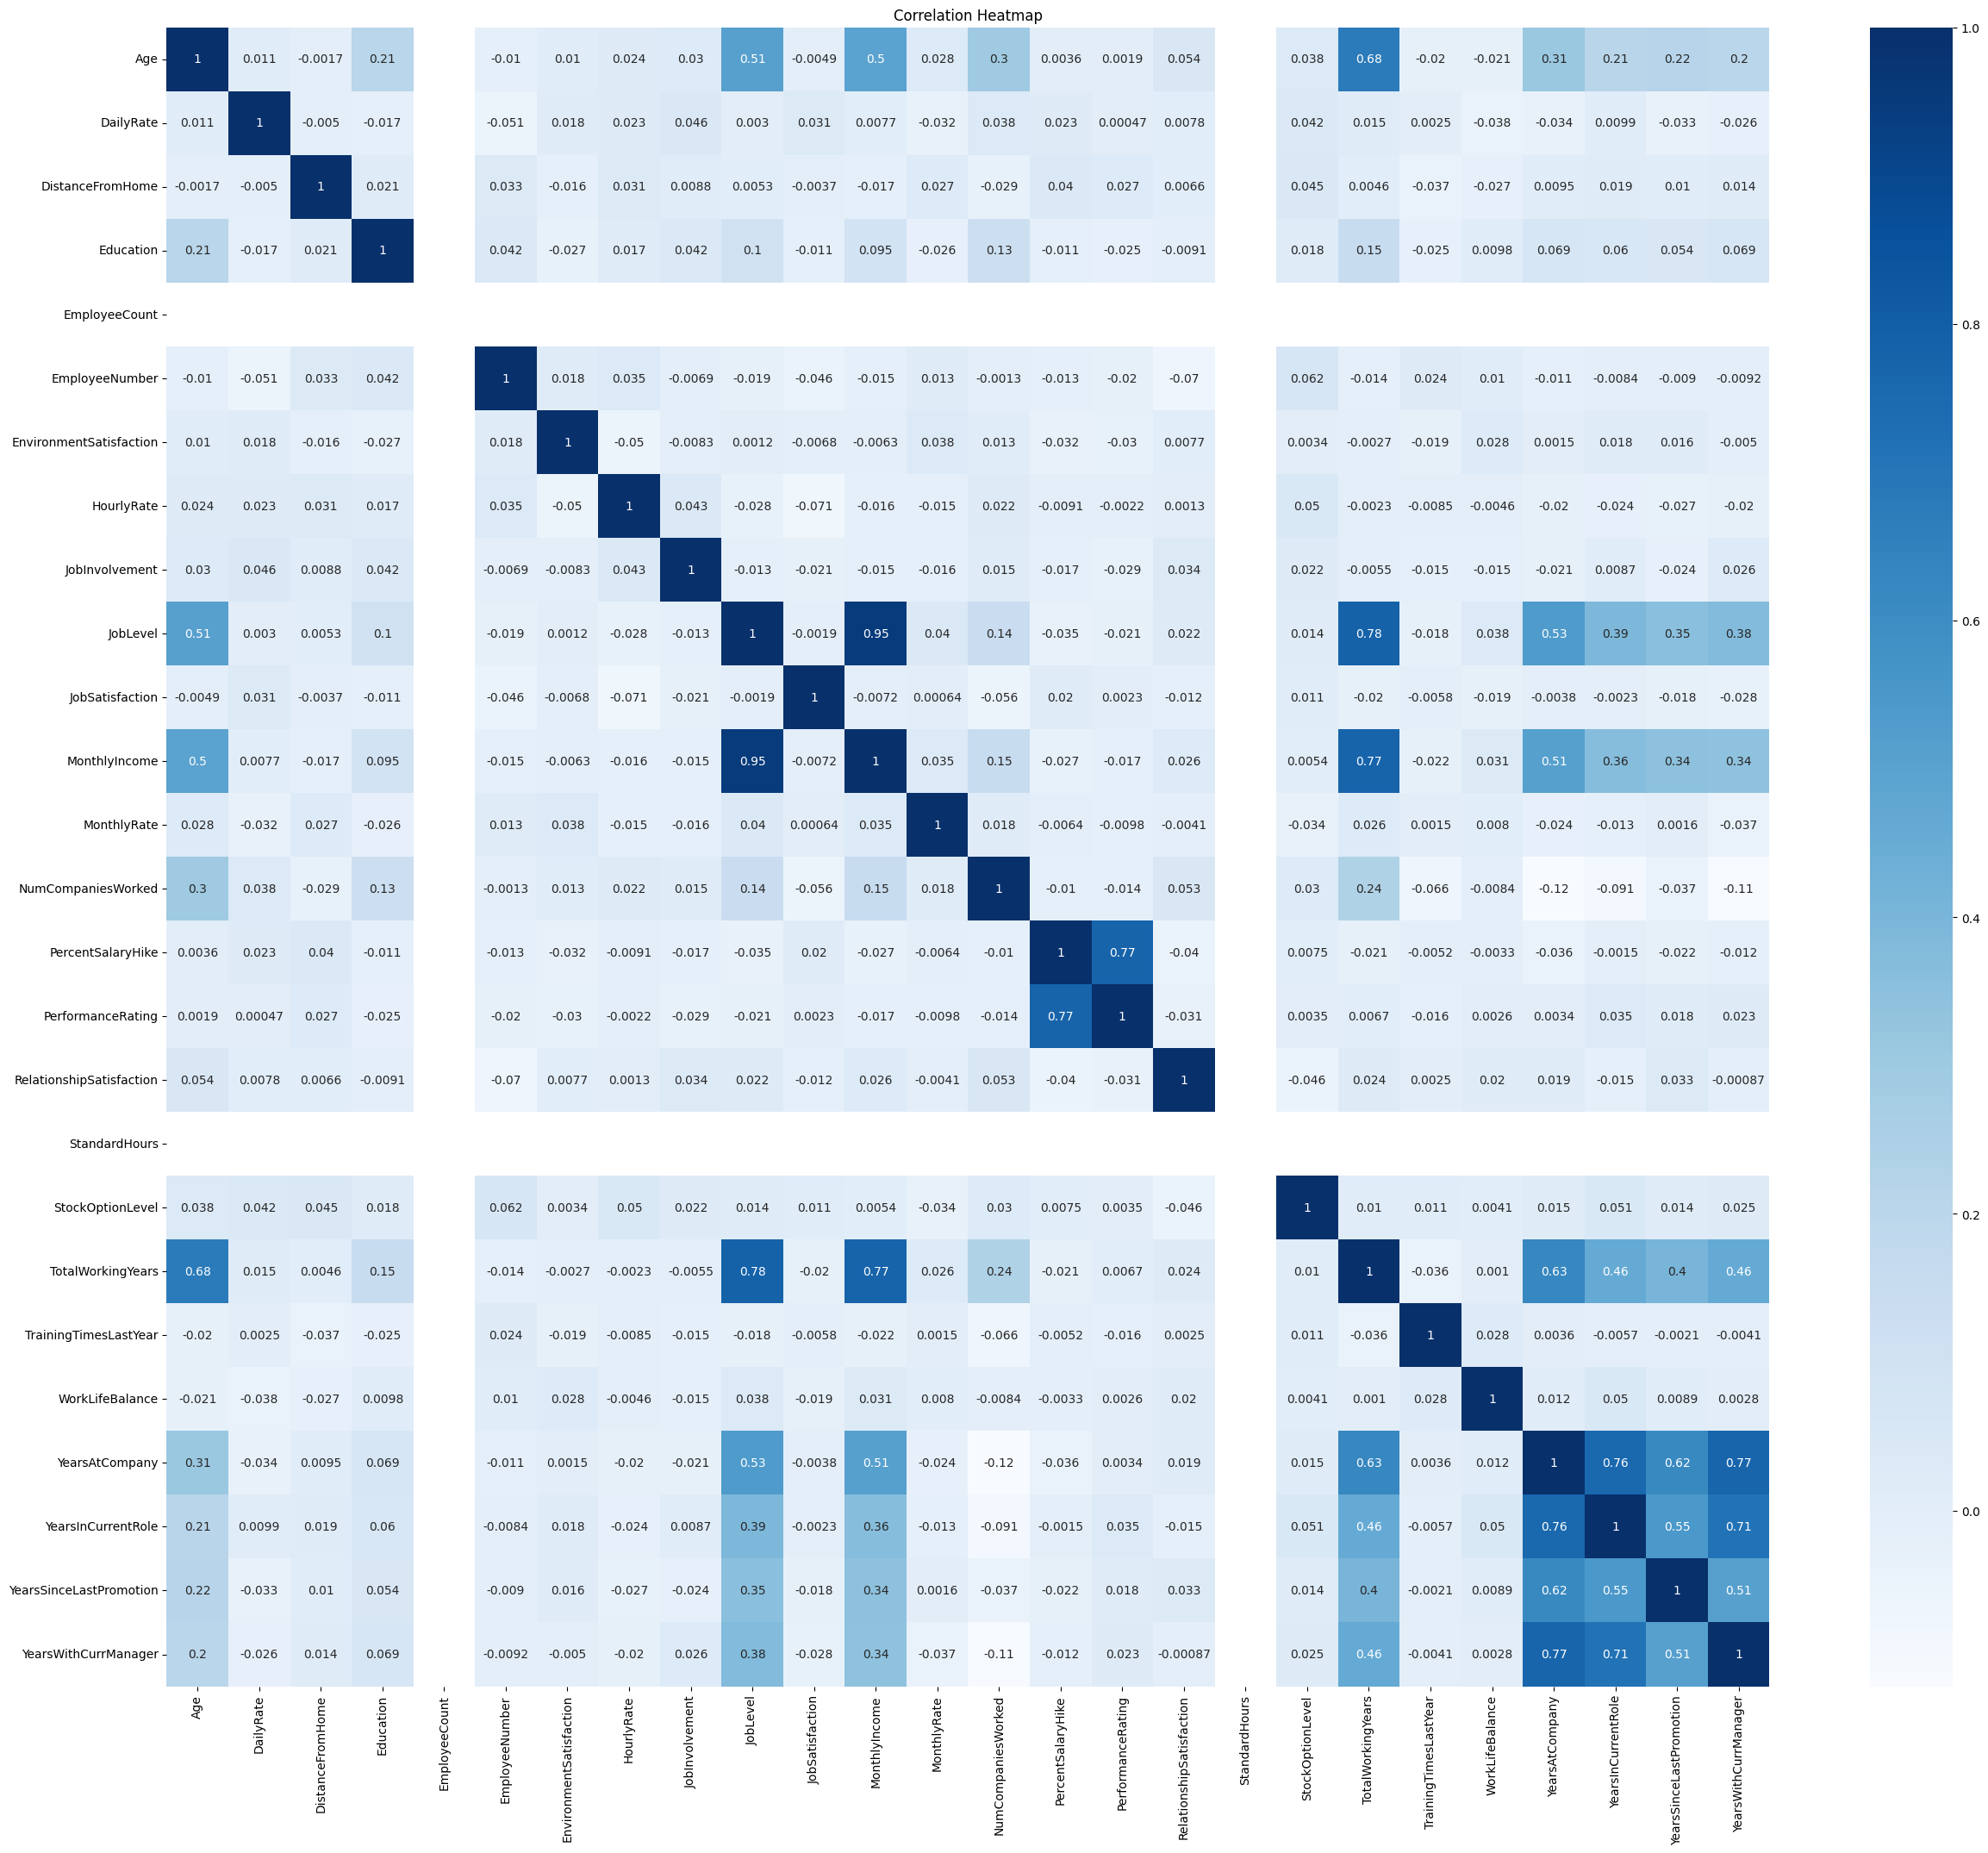

In [ ]:
# Correlation Heatmap of numerical features
corr = data.select_dtypes(include=['int64']).corr()
plt.figure(figsize=(30,25))
sns.heatmap(corr, annot=True, cmap='Blues')
plt.title("Correlation Heatmap")
plt.show()

**Insights**
* Strong positive correlation between Job Level and Monthly Income, indicating higher job roles are associated with higher salaries

* Total Working Years shows a strong positive relationship with Age, meaning experience increases as age increases

* Years at Company, Years in Current Role, and Years with Current Manager are highly correlated, showing consistency in employee tenure progression

* Most other variables have weak or near-zero correlations, suggesting limited linear relationships among them


# **9. Detect and Handle Outliers**

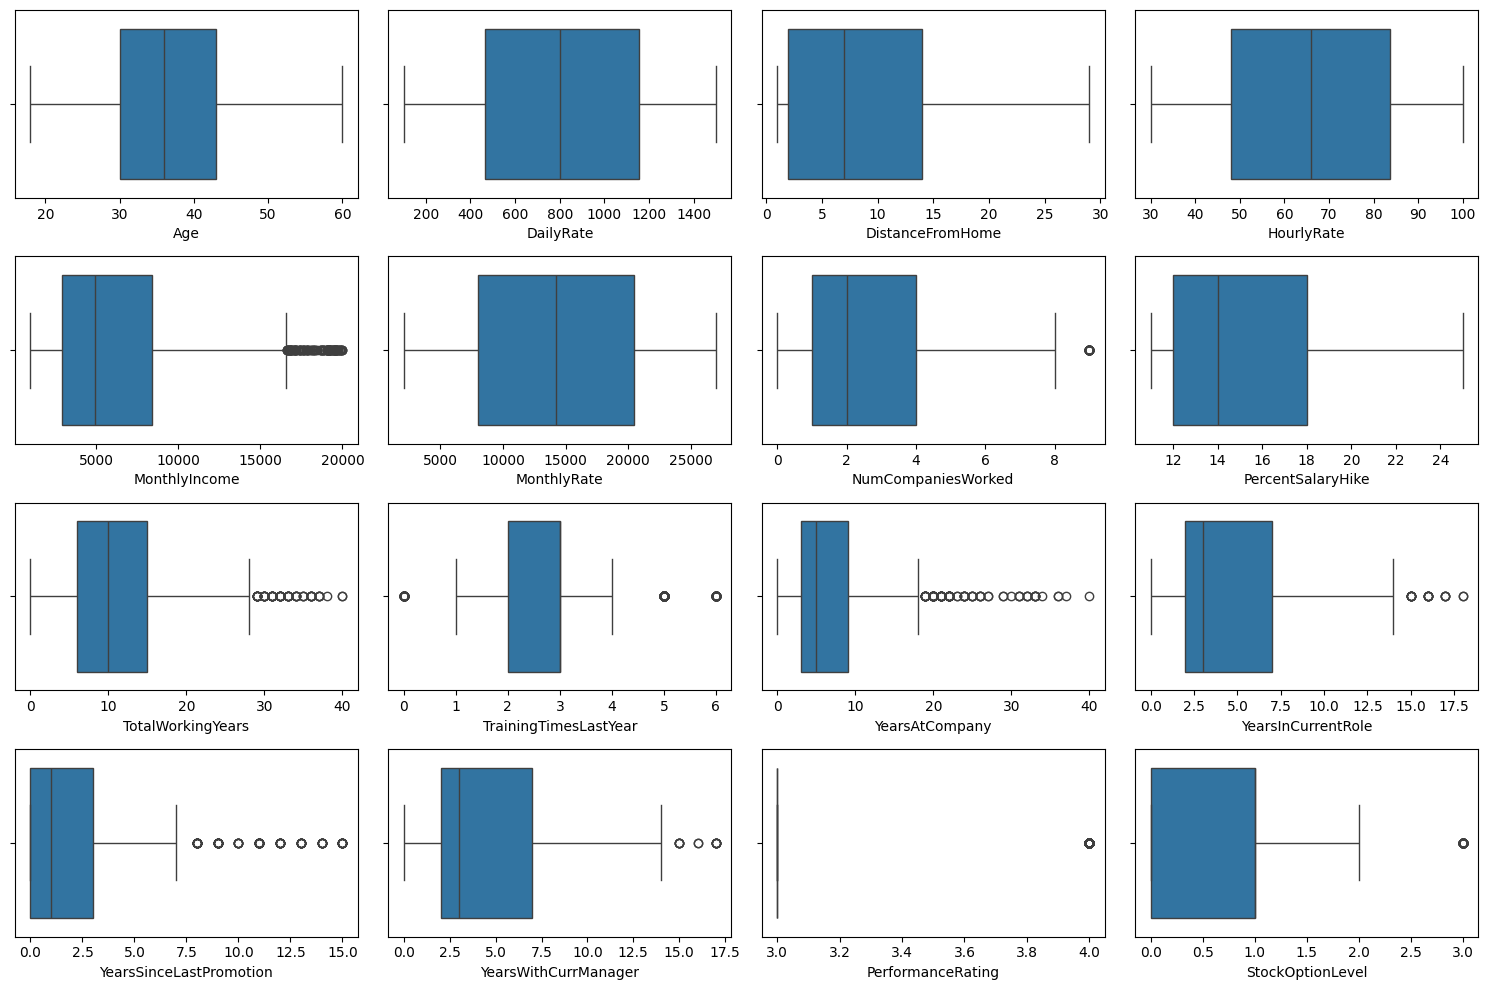

In [ ]:
fig, ax = plt.subplots(4, 4, figsize=(15,10))
sns.boxplot(data=data, x='Age', ax=ax[0,0])
sns.boxplot(data=data, x='DailyRate', ax=ax[0,1])
sns.boxplot(data=data, x='DistanceFromHome', ax=ax[0,2])
sns.boxplot(data=data, x='HourlyRate', ax=ax[0,3])

sns.boxplot(data=data, x='MonthlyIncome', ax=ax[1,0])
sns.boxplot(data=data, x='MonthlyRate', ax=ax[1,1])
sns.boxplot(data=data, x='NumCompaniesWorked', ax=ax[1,2])
sns.boxplot(data=data, x='PercentSalaryHike', ax=ax[1,3])

sns.boxplot(data=data, x='TotalWorkingYears', ax=ax[2,0])
sns.boxplot(data=data, x='TrainingTimesLastYear', ax=ax[2,1])
sns.boxplot(data=data, x='YearsAtCompany', ax=ax[2,2])
sns.boxplot(data=data, x='YearsInCurrentRole', ax=ax[2,3])

sns.boxplot(data=data, x='YearsSinceLastPromotion', ax=ax[3,0])
sns.boxplot(data=data, x='YearsWithCurrManager', ax=ax[3,1])
sns.boxplot(data=data, x='PerformanceRating', ax=ax[3,2])
sns.boxplot(data=data, x='StockOptionLevel', ax=ax[3,3])

plt.tight_layout()
plt.show()

There are **outliers** in **'MonthlyIncome','TotalWorkingYears','NumCompaniesWorked','TrainingTimesLastYear','YearsAtCompany','YearsInCurrentRole','YearsSinceLastPromotion','YearsWithCurrManager','StockOptionLevel','PerformanceRating'**

**Check the distribution**

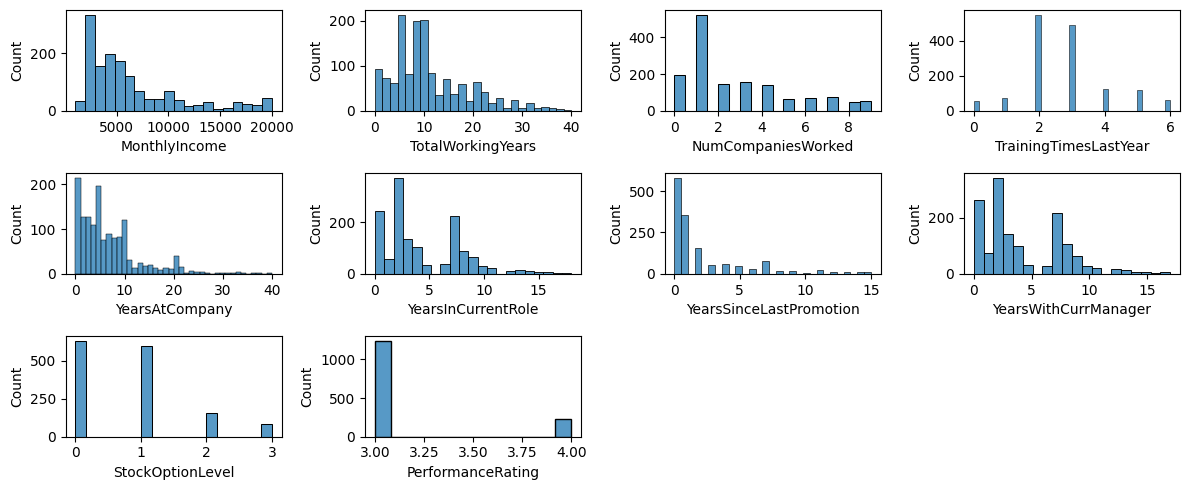

In [ ]:
df = data[['MonthlyIncome','TotalWorkingYears','NumCompaniesWorked',
           'TrainingTimesLastYear','YearsAtCompany','YearsInCurrentRole',
           'YearsSinceLastPromotion','YearsWithCurrManager',
           'StockOptionLevel','PerformanceRating']]
fig, ax = plt.subplots(3, 4, figsize=(12,5))

sns.histplot(df, x='MonthlyIncome', ax=ax[0,0])
sns.histplot(df, x='TotalWorkingYears', ax=ax[0,1])
sns.histplot(df, x='NumCompaniesWorked', ax=ax[0,2])
sns.histplot(df, x='TrainingTimesLastYear', ax=ax[0,3])

sns.histplot(df, x='YearsAtCompany', ax=ax[1,0])
sns.histplot(df, x='YearsInCurrentRole', ax=ax[1,1])
sns.histplot(df, x='YearsSinceLastPromotion', ax=ax[1,2])
sns.histplot(df, x='YearsWithCurrManager', ax=ax[1,3])

sns.histplot(df, x='StockOptionLevel', ax=ax[2,0])
sns.histplot(df, x='PerformanceRating', ax=ax[2,1])

# empty plots
ax[2,2].axis('off')
ax[2,3].axis('off')

plt.tight_layout()
plt.show()

**Skewness**

In [ ]:
df = data[['MonthlyIncome','TotalWorkingYears','NumCompaniesWorked',
           'TrainingTimesLastYear','YearsAtCompany','YearsInCurrentRole',
           'YearsSinceLastPromotion','YearsWithCurrManager','PerformanceRating',
           'StockOptionLevel']]
for x in df:
  print(x,df[x].skew())

MonthlyIncome 1.3698166808390662
TotalWorkingYears 1.1171718528128527
NumCompaniesWorked 1.026471111968205
TrainingTimesLastYear 0.5531241710537028
YearsAtCompany 1.7645294543422085
YearsInCurrentRole 0.9173631562908262
YearsSinceLastPromotion 1.9842899833524859
YearsWithCurrManager 0.8334509919918475
PerformanceRating 1.921882702142603
StockOptionLevel 0.9689803167738937


**MonthlyIncome distribution is skewed**

In [ ]:
#IQR
Q1  = data.loc[:,'MonthlyIncome'].quantile(0.25)
Q3  = data.loc[:,'MonthlyIncome'].quantile(0.75)
IQR = Q3-Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

In [ ]:
# filter all values greater than upper limit
data[data.loc[:,'MonthlyIncome']>upper_limit]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
25,53,No,Travel_Rarely,1282,Research & Development,5,3,Other,1,32,...,4,80,1,26,3,2,14,13,4,8
29,46,No,Travel_Rarely,705,Sales,2,4,Marketing,1,38,...,4,80,0,22,2,2,2,2,2,1
45,41,Yes,Travel_Rarely,1360,Research & Development,12,3,Technical Degree,1,58,...,4,80,0,23,0,3,22,15,15,8
62,50,No,Travel_Rarely,989,Research & Development,7,2,Medical,1,80,...,4,80,1,29,2,2,27,3,13,8
105,59,No,Non-Travel,1420,Human Resources,2,4,Human Resources,1,140,...,4,80,1,30,3,3,3,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1374,58,No,Travel_Rarely,605,Sales,21,3,Life Sciences,1,1938,...,3,80,1,29,2,2,1,0,0,0
1377,49,No,Travel_Frequently,1064,Research & Development,2,1,Life Sciences,1,1941,...,4,80,0,28,3,3,5,4,4,3
1401,55,No,Travel_Rarely,189,Human Resources,26,4,Human Resources,1,1973,...,1,80,1,35,0,3,10,9,1,4
1437,39,No,Non-Travel,105,Research & Development,9,3,Life Sciences,1,2022,...,3,80,0,21,3,2,6,0,1,3


In [ ]:
# filter all values less than lower_limit
data[data.loc[:,'MonthlyIncome']<lower_limit]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager


In [ ]:
# find %
len(data[(data.loc[:,'MonthlyIncome']>upper_limit)|(data.loc[:,'MonthlyIncome']<lower_limit)])/len(data)*100

7.755102040816326

Since % of outliers are more than 5% i.e 7% they are not outliers they are adding some meaning to the data.

**TotalWorkingYears distribution is skewed**

In [ ]:
# find outliers in TotalWorkingYears
Q1 = data.loc[:,'TotalWorkingYears'].quantile(0.25)
Q3 = data.loc[:,'TotalWorkingYears'].quantile(0.75)
IQR = Q3-Q1
lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5* IQR

In [ ]:
# filter values less than lower limit
data[data.loc[:,'TotalWorkingYears']<lower_limit]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager


In [ ]:
# filter values greater than upper limit
data[data.loc[:,'TotalWorkingYears']>upper_limit]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
18,53,No,Travel_Rarely,1219,Sales,2,4,Life Sciences,1,23,...,3,80,0,31,3,3,25,8,3,7
62,50,No,Travel_Rarely,989,Research & Development,7,2,Medical,1,80,...,4,80,1,29,2,2,27,3,13,8
85,56,No,Travel_Rarely,1400,Research & Development,7,3,Life Sciences,1,112,...,1,80,0,37,3,2,6,4,0,2
98,58,No,Travel_Rarely,682,Sales,10,4,Medical,1,131,...,3,80,0,38,1,2,37,10,1,8
105,59,No,Non-Travel,1420,Human Resources,2,4,Human Resources,1,140,...,4,80,1,30,3,3,3,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1264,55,No,Travel_Rarely,478,Research & Development,2,3,Medical,1,1770,...,2,80,3,34,2,3,1,0,0,0
1301,58,No,Non-Travel,350,Sales,2,3,Medical,1,1824,...,4,80,1,37,0,2,16,9,14,14
1331,48,No,Travel_Rarely,1224,Research & Development,10,3,Life Sciences,1,1867,...,4,80,0,29,3,3,22,10,12,9
1374,58,No,Travel_Rarely,605,Sales,21,3,Life Sciences,1,1938,...,3,80,1,29,2,2,1,0,0,0


In [ ]:
# find %
len(data[(data.loc[:,'TotalWorkingYears']>upper_limit)|(data.loc[:,'TotalWorkingYears']<lower_limit)])/len(data)*100

4.285714285714286

Since % of outliers are less 5% i.e 4% lets fill with median.

In [ ]:
# fill with median
data.loc[(data.loc[:,'TotalWorkingYears']<lower_limit) |
 (data.loc[:,'TotalWorkingYears']>upper_limit),'TotalWorkingYears']=data.loc[:,'TotalWorkingYears'].median()

In [ ]:
len(data[(data.loc[:,'TotalWorkingYears']<lower_limit) | (data.loc[:,'TotalWorkingYears']> upper_limit)])/len(data)*100

0.0

**NumCompaniesWorked distribution is skewed**

In [ ]:
# find outliers in NumCompaniesWorked
Q1 = data.loc[:,'NumCompaniesWorked'].quantile(0.25)
Q3 = data.loc[:,'NumCompaniesWorked'].quantile(0.75)
IQR = Q3-Q1
lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5* IQR

In [ ]:
# filter values less than lower limit
data[data.loc[:,'NumCompaniesWorked']<lower_limit]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager


In [ ]:
# filter values greater than upper limit
data[data.loc[:,'NumCompaniesWorked']>upper_limit]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
38,36,No,Travel_Rarely,852,Research & Development,5,4,Life Sciences,1,51,...,4,80,1,6,3,4,1,1,0,0
50,48,Yes,Travel_Rarely,626,Research & Development,1,2,Life Sciences,1,64,...,4,80,0,23,2,3,1,0,0,0
95,54,No,Travel_Rarely,1217,Research & Development,2,4,Technical Degree,1,126,...,1,80,1,16,5,1,4,3,0,3
105,59,No,Non-Travel,1420,Human Resources,2,4,Human Resources,1,140,...,4,80,1,10,3,3,3,2,2,2
122,56,Yes,Travel_Rarely,441,Research & Development,14,4,Life Sciences,1,161,...,1,80,3,7,2,3,5,4,4,3
194,45,No,Non-Travel,1195,Research & Development,2,2,Medical,1,264,...,4,80,1,22,1,3,20,8,11,8
198,38,No,Travel_Rarely,1261,Research & Development,2,4,Life Sciences,1,271,...,2,80,0,14,3,3,1,0,0,0
208,40,No,Non-Travel,1151,Research & Development,9,5,Life Sciences,1,287,...,4,80,1,5,5,1,3,2,0,2
245,31,No,Travel_Frequently,1327,Research & Development,3,4,Medical,1,337,...,1,80,1,9,3,3,2,2,2,2


In [ ]:
# find %
len(data[(data.loc[:,'NumCompaniesWorked']>upper_limit)|(data.loc[:,'NumCompaniesWorked']<lower_limit)])/len(data)*100

3.537414965986395

Since % of outliers are less 5% i.e 3% lets fill with median.

In [ ]:
# fill with median
data.loc[(data.loc[:,'NumCompaniesWorked']<lower_limit) |
 (data.loc[:,'NumCompaniesWorked']>upper_limit),'NumCompaniesWorked']=data.loc[:,'NumCompaniesWorked'].median()

In [ ]:
len(data[(data.loc[:,'NumCompaniesWorked']>upper_limit)|(data.loc[:,'NumCompaniesWorked']<lower_limit)])/len(data)*100

0.0

**TrainingTimesLastYear distribution is skewed**

In [ ]:
#IQR
Q1  = data.loc[:,'TrainingTimesLastYear'].quantile(0.25)
Q3  = data.loc[:,'TrainingTimesLastYear'].quantile(0.75)
IQR = Q3-Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

In [ ]:
# filter all values greater than upper limit
data[data.loc[:,'TrainingTimesLastYear']>upper_limit]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
10,35,No,Travel_Rarely,809,Research & Development,16,3,Medical,1,14,...,3,80,1,6,5,3,5,4,0,3
16,32,No,Travel_Rarely,334,Research & Development,5,2,Life Sciences,1,21,...,4,80,2,7,5,2,6,2,0,5
20,24,No,Non-Travel,673,Research & Development,11,2,Other,1,26,...,4,80,1,5,5,2,4,2,1,3
23,21,No,Travel_Rarely,391,Research & Development,15,2,Life Sciences,1,30,...,4,80,0,0,6,3,0,0,0,0
26,32,Yes,Travel_Frequently,1125,Research & Development,16,1,Life Sciences,1,33,...,2,80,0,10,5,3,10,2,6,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1425,33,No,Travel_Rarely,501,Research & Development,15,2,Medical,1,2009,...,1,80,1,10,6,3,9,7,8,1
1436,21,No,Travel_Rarely,501,Sales,5,1,Medical,1,2021,...,4,80,0,2,6,3,2,2,1,2
1448,41,No,Travel_Rarely,930,Sales,3,3,Life Sciences,1,2037,...,3,80,1,14,5,3,5,4,0,4
1458,35,No,Travel_Rarely,287,Research & Development,1,4,Life Sciences,1,2052,...,4,80,1,4,5,3,4,3,1,1


In [ ]:
# filter all values less than lower_limit
data[data.loc[:,'TrainingTimesLastYear']<lower_limit]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
43,27,No,Travel_Frequently,994,Sales,8,3,Life Sciences,1,56,...,4,80,0,9,0,3,9,8,1,7
45,41,Yes,Travel_Rarely,1360,Research & Development,12,3,Technical Degree,1,58,...,4,80,0,23,0,3,22,15,15,8
69,36,Yes,Travel_Rarely,318,Research & Development,9,3,Medical,1,90,...,1,80,1,2,0,2,1,0,0,0
94,32,No,Travel_Rarely,1093,Sales,6,4,Medical,1,125,...,1,80,0,12,0,3,11,8,5,7
135,36,No,Travel_Rarely,216,Research & Development,6,2,Medical,1,178,...,4,80,2,7,0,3,3,2,0,1
180,31,No,Travel_Rarely,140,Research & Development,12,1,Medical,1,246,...,3,80,1,7,0,3,4,2,0,2
201,49,No,Non-Travel,1002,Research & Development,18,4,Life Sciences,1,275,...,1,80,2,7,0,3,7,7,1,7
258,51,No,Travel_Rarely,833,Research & Development,1,3,Life Sciences,1,353,...,2,80,0,1,0,2,1,0,0,0
261,38,No,Non-Travel,1327,Sales,2,2,Life Sciences,1,361,...,4,80,1,13,0,3,8,7,7,5


In [ ]:
# find %
len(data[(data.loc[:,'TrainingTimesLastYear']>upper_limit)|(data.loc[:,'TrainingTimesLastYear']<lower_limit)])/len(data)*100

16.19047619047619

Since % of outliers are more than 5% i.e 16% they are not outliers they are adding some meaning to the data.

**YearsAtCompany distribution is skewed**

In [ ]:
#IQR
Q1  = data.loc[:,'YearsAtCompany'].quantile(0.25)
Q3  = data.loc[:,'YearsAtCompany'].quantile(0.75)
IQR = Q3-Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

In [ ]:
# filter all values greater than upper limit
data[data.loc[:,'YearsAtCompany']>upper_limit]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
18,53,No,Travel_Rarely,1219,Sales,2,4,Life Sciences,1,23,...,3,80,0,10,3,3,25,8,3,7
28,44,No,Travel_Rarely,477,Research & Development,7,4,Medical,1,36,...,4,80,1,24,4,3,22,6,5,17
45,41,Yes,Travel_Rarely,1360,Research & Development,12,3,Technical Degree,1,58,...,4,80,0,23,0,3,22,15,15,8
62,50,No,Travel_Rarely,989,Research & Development,7,2,Medical,1,80,...,4,80,1,10,2,2,27,3,13,8
63,59,No,Travel_Rarely,1435,Sales,25,3,Life Sciences,1,81,...,4,80,0,28,3,2,21,16,7,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1403,39,No,Travel_Rarely,119,Sales,15,4,Marketing,1,1975,...,1,80,0,21,3,3,20,8,11,10
1404,42,No,Non-Travel,335,Research & Development,23,2,Life Sciences,1,1976,...,4,80,0,20,2,3,20,9,3,7
1443,42,No,Travel_Rarely,300,Research & Development,2,3,Life Sciences,1,2031,...,1,80,0,24,2,2,22,6,4,14
1445,41,No,Travel_Rarely,582,Research & Development,28,4,Life Sciences,1,2034,...,3,80,1,21,3,3,20,7,0,10


In [ ]:
# filter all values less than lower_limit
data[data.loc[:,'YearsAtCompany']<lower_limit]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager


In [ ]:
# find %
len(data[(data.loc[:,'YearsAtCompany']>upper_limit)|(data.loc[:,'YearsAtCompany']<lower_limit)])/len(data)*100

7.07482993197279

Since % of outliers are more than 5% i.e 7% they are not outliers they are adding some meaning to the data.

**YearsInCurrentRole distribution is skewed**

In [ ]:
#IQR
Q1  = data.loc[:,'YearsInCurrentRole'].quantile(0.25)
Q3  = data.loc[:,'YearsInCurrentRole'].quantile(0.75)
IQR = Q3-Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

In [ ]:
# filter all values greater than upper limit
data[data.loc[:,'YearsInCurrentRole']>upper_limit]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
45,41,Yes,Travel_Rarely,1360,Research & Development,12,3,Technical Degree,1,58,...,4,80,0,23,0,3,22,15,15,8
63,59,No,Travel_Rarely,1435,Sales,25,3,Life Sciences,1,81,...,4,80,0,28,3,2,21,16,7,9
123,51,No,Travel_Rarely,684,Research & Development,6,3,Life Sciences,1,162,...,3,80,0,23,5,3,20,18,15,15
187,55,No,Travel_Rarely,692,Research & Development,14,4,Medical,1,254,...,4,80,0,10,3,3,24,15,2,15
190,52,No,Travel_Rarely,699,Research & Development,1,4,Life Sciences,1,259,...,1,80,1,10,5,3,33,18,11,9
231,42,No,Travel_Rarely,532,Research & Development,4,2,Technical Degree,1,319,...,4,80,0,22,3,3,22,17,11,15
281,42,No,Travel_Rarely,635,Sales,1,1,Life Sciences,1,387,...,3,80,0,20,3,3,20,16,11,6
417,40,No,Travel_Rarely,1398,Sales,2,4,Life Sciences,1,558,...,4,80,0,21,2,3,20,15,1,12
466,41,No,Travel_Rarely,1276,Sales,2,5,Life Sciences,1,625,...,2,80,1,22,2,3,18,16,11,8
595,58,Yes,Travel_Rarely,286,Research & Development,2,4,Life Sciences,1,825,...,4,80,0,10,2,3,31,15,13,8


In [ ]:
# filter all values less than lower_limit
data[data.loc[:,'YearsInCurrentRole']<lower_limit]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager


In [ ]:
# find %
len(data[(data.loc[:,'YearsInCurrentRole']>upper_limit)|(data.loc[:,'YearsInCurrentRole']<lower_limit)])/len(data)*100

1.4285714285714286

Since % of outliers are less 5% i.e 1% lets fill with median.

In [ ]:
# fill with median
data.loc[(data.loc[:,'YearsInCurrentRole']<lower_limit) |
 (data.loc[:,'YearsInCurrentRole']>upper_limit),'YearsInCurrentRole']=data.loc[:,'YearsInCurrentRole'].median()

In [ ]:
len(data[(data.loc[:,'YearsInCurrentRole']>upper_limit)|(data.loc[:,'YearsInCurrentRole']<lower_limit)])/len(data)*100

0.0

**YearsSinceLastPromotion distribution is skewed**

In [ ]:
#IQR
Q1  = data.loc[:,'YearsSinceLastPromotion'].quantile(0.25)
Q3  = data.loc[:,'YearsSinceLastPromotion'].quantile(0.75)
IQR = Q3-Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

In [ ]:
# filter all values greater than upper limit
data[data.loc[:,'YearsSinceLastPromotion']>upper_limit]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
15,29,No,Travel_Rarely,1389,Research & Development,21,4,Life Sciences,1,20,...,3,80,1,10,1,3,10,9,8,8
45,41,Yes,Travel_Rarely,1360,Research & Development,12,3,Technical Degree,1,58,...,4,80,0,23,0,3,22,3,15,8
46,34,No,Non-Travel,1065,Sales,23,4,Marketing,1,60,...,3,80,0,10,2,3,9,5,8,7
55,33,No,Travel_Frequently,515,Research & Development,1,2,Life Sciences,1,73,...,3,80,0,15,1,3,15,14,8,12
61,38,No,Travel_Frequently,653,Research & Development,29,5,Life Sciences,1,79,...,4,80,0,10,2,3,10,3,9,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1414,47,No,Travel_Rarely,1180,Research & Development,25,3,Medical,1,1993,...,2,80,0,25,3,3,17,14,12,11
1425,33,No,Travel_Rarely,501,Research & Development,15,2,Medical,1,2009,...,1,80,1,10,6,3,9,7,8,1
1444,56,Yes,Travel_Rarely,310,Research & Development,7,2,Technical Degree,1,2032,...,4,80,1,14,4,1,10,9,9,8
1447,36,No,Non-Travel,301,Sales,15,4,Marketing,1,2036,...,1,80,1,15,4,2,15,12,11,11


In [ ]:
# filter all values less than lower_limit
data[data.loc[:,'YearsSinceLastPromotion']<lower_limit]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager


In [ ]:
# find %
len(data[(data.loc[:,'YearsSinceLastPromotion']>upper_limit)|(data.loc[:,'YearsSinceLastPromotion']<lower_limit)])/len(data)*100

7.278911564625851

Since % of outliers are more than 5% i.e 7% they are not outliers they are adding some meaning to the data.

**YearsWithCurrManager distribution is skewed**

In [ ]:
#IQR
Q1  = data.loc[:,'YearsWithCurrManager'].quantile(0.25)
Q3  = data.loc[:,'YearsWithCurrManager'].quantile(0.75)
IQR = Q3-Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

In [ ]:
# filter all values greater than upper limit
data[data.loc[:,'YearsWithCurrManager']>upper_limit]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
28,44,No,Travel_Rarely,477,Research & Development,7,4,Medical,1,36,...,4,80,1,24,4,3,22,6,5,17
123,51,No,Travel_Rarely,684,Research & Development,6,3,Life Sciences,1,162,...,3,80,0,23,5,3,20,3,15,15
153,45,No,Travel_Rarely,194,Research & Development,9,3,Life Sciences,1,206,...,3,80,1,20,2,1,17,9,0,15
187,55,No,Travel_Rarely,692,Research & Development,14,4,Medical,1,254,...,4,80,0,10,3,3,24,3,2,15
231,42,No,Travel_Rarely,532,Research & Development,4,2,Technical Degree,1,319,...,4,80,0,22,3,3,22,3,11,15
386,37,No,Travel_Rarely,1107,Research & Development,14,3,Life Sciences,1,515,...,3,80,1,18,2,2,18,7,12,17
561,52,No,Travel_Rarely,621,Sales,3,4,Marketing,1,776,...,1,80,0,10,3,4,34,6,1,16
616,51,No,Travel_Rarely,1318,Sales,26,4,Marketing,1,851,...,3,80,1,10,2,2,20,6,4,17
635,35,No,Travel_Rarely,607,Research & Development,9,3,Life Sciences,1,880,...,2,80,1,17,2,3,17,14,5,15
686,41,No,Travel_Rarely,263,Research & Development,6,3,Medical,1,957,...,3,80,0,20,3,3,18,13,2,17


In [ ]:
# filter all values less than lower_limit
data[data.loc[:,'YearsWithCurrManager']<lower_limit]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager


In [ ]:
# find %
len(data[(data.loc[:,'YearsWithCurrManager']>upper_limit)|(data.loc[:,'YearsWithCurrManager']<lower_limit)])/len(data)*100

0.9523809523809524

Since % of outliers are less 5% i.e 0.9% lets fill with median.

In [ ]:
# fill with median
data.loc[(data.loc[:,'YearsWithCurrManager']<lower_limit) |
 (data.loc[:,'YearsWithCurrManager']>upper_limit),'YearsWithCurrManager']=data.loc[:,'YearsWithCurrManager'].median()

In [ ]:
len(data[(data.loc[:,'YearsWithCurrManager']>upper_limit)|(data.loc[:,'YearsWithCurrManager']<lower_limit)])/len(data)*100

0.0

**StockOptionLevel distribution is skewed**

In [ ]:
#IQR
Q1  = data.loc[:,'StockOptionLevel'].quantile(0.25)
Q3  = data.loc[:,'StockOptionLevel'].quantile(0.75)
IQR = Q3-Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

In [ ]:
# filter all values greater than upper limit
data[data.loc[:,'StockOptionLevel']>upper_limit]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
64,36,No,Travel_Rarely,1223,Research & Development,8,3,Technical Degree,1,83,...,2,80,3,17,2,3,17,14,12,8
65,55,No,Travel_Rarely,836,Research & Development,8,3,Medical,1,84,...,3,80,3,21,2,3,5,0,0,2
83,38,No,Non-Travel,573,Research & Development,6,3,Medical,1,107,...,4,80,3,17,3,3,13,11,1,9
88,30,No,Travel_Rarely,288,Research & Development,2,3,Life Sciences,1,117,...,1,80,3,11,3,3,11,10,10,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1402,31,No,Travel_Rarely,1276,Research & Development,2,1,Medical,1,1974,...,3,80,3,1,4,3,1,0,0,0
1415,33,No,Non-Travel,1313,Research & Development,1,2,Medical,1,1994,...,3,80,3,1,2,2,1,1,0,0
1440,36,No,Travel_Frequently,688,Research & Development,4,2,Life Sciences,1,2025,...,2,80,3,18,3,3,4,2,0,2
1442,29,Yes,Travel_Rarely,1092,Research & Development,1,4,Medical,1,2027,...,2,80,3,4,3,4,2,2,2,2


In [ ]:
# filter all values less than lower_limit
data[data.loc[:,'StockOptionLevel']<lower_limit]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager


In [ ]:
# find %
len(data[(data.loc[:,'StockOptionLevel']>upper_limit)|(data.loc[:,'StockOptionLevel']<lower_limit)])/len(data)*100

5.782312925170068

Since % of outliers are more than 5% i.e 5.7% they are not outliers they are adding some meaning to the data.

**PerformanceRating distribution is skewed**

In [ ]:
#IQR
Q1  = data.loc[:,'PerformanceRating'].quantile(0.25)
Q3  = data.loc[:,'PerformanceRating'].quantile(0.75)
IQR = Q3-Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

In [ ]:
# filter all values greater than upper limit
data[data.loc[:,'PerformanceRating']>upper_limit]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
21,36,Yes,Travel_Rarely,1218,Sales,9,4,Life Sciences,1,27,...,2,80,0,10,4,3,5,3,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1441,56,No,Non-Travel,667,Research & Development,1,4,Life Sciences,1,2026,...,1,80,1,13,2,2,13,12,1,9
1445,41,No,Travel_Rarely,582,Research & Development,28,4,Life Sciences,1,2034,...,3,80,1,21,3,3,20,7,0,10
1446,34,No,Travel_Rarely,704,Sales,28,3,Marketing,1,2035,...,4,80,2,8,2,3,8,7,1,7
1447,36,No,Non-Travel,301,Sales,15,4,Marketing,1,2036,...,1,80,1,15,4,2,15,12,11,11


In [ ]:
# filter all values less than lower_limit
data[data.loc[:,'PerformanceRating']<lower_limit]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager


In [ ]:
# find %
len(data[(data.loc[:,'PerformanceRating']>upper_limit)|(data.loc[:,'PerformanceRating']<lower_limit)])/len(data)*100

15.374149659863946

Since % of outliers are more than 5% i.e 15% they are not outliers they are adding some meaning to the data.

# **10. Encoding**

In [ ]:
data.dtypes

,0
Age,int64
Attrition,object
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EmployeeCount,int64
EmployeeNumber,int64


**Attrition, Gender, OverTime - Label Encoder**

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data.loc[:,'attrition']= le.fit_transform(data.loc[:,'Attrition'])
data.loc[:,'gender']= le.fit_transform(data.loc[:,'Gender'])
data.loc[:,'overTime']= le.fit_transform(data.loc[:,'OverTime'])

In [ ]:
data.drop(columns=['Attrition','Gender','OverTime'],inplace=True)

**BusinessTravel, Department, EducationField, JobRole, MaritalStatus - One-Hot Encoding**

In [ ]:
data =pd.get_dummies(data,columns=['BusinessTravel','Department','EducationField','JobRole','MaritalStatus'],dtype='int')

In [ ]:
data.dtypes

,0
Age,int64
DailyRate,int64
DistanceFromHome,int64
Education,int64
EmployeeCount,int64
EmployeeNumber,int64
EnvironmentSatisfaction,int64
HourlyRate,int64
JobInvolvement,int64
JobLevel,int64


In [ ]:
data

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,41,1102,1,2,1,1,2,94,3,2,...,0,0,0,0,0,1,0,0,0,1
1,49,279,8,1,1,2,3,61,2,2,...,0,0,0,0,1,0,0,0,1,0
2,37,1373,2,2,1,4,4,92,2,1,...,1,0,0,0,0,0,0,0,0,1
3,33,1392,3,4,1,5,4,56,3,1,...,0,0,0,0,1,0,0,0,1,0
4,27,591,2,1,1,7,1,40,3,1,...,1,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,884,23,2,1,2061,3,41,4,2,...,1,0,0,0,0,0,0,0,1,0
1466,39,613,6,1,1,2062,4,42,2,3,...,0,0,0,0,0,0,0,0,1,0
1467,27,155,4,3,1,2064,2,87,4,2,...,0,0,1,0,0,0,0,0,1,0
1468,49,1023,2,3,1,2065,4,63,2,2,...,0,0,0,0,0,1,0,0,1,0


# **11. Feature Selection**

In [ ]:
cols_to_drop = ['Over18', 'EmployeeCount', 'StandardHours', 'EmployeeNumber']
data.drop(cols_to_drop, axis=1, inplace=True)

# **12. Separate Features and Target Variable**

**Split Data for X and Y**

In [ ]:
x=data.drop(columns='attrition')
y=data.loc[:,'attrition']

# **13. Train-Test Split**

**Split Data for Training and Testing**

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
data.shape

(1470, 50)

In [ ]:
x_train.shape

(1176, 49)

In [ ]:
x_test.shape

(294, 49)

In [ ]:
y_train.shape

(1176,)

In [ ]:
y_test.shape

(294,)

# **14. Balancing data**

<Axes: xlabel='attrition', ylabel='count'>

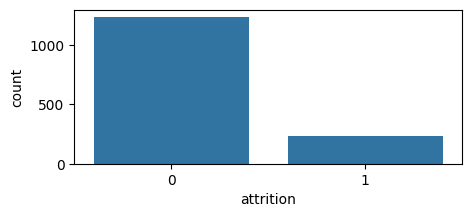

In [ ]:
# plot count plot for target
plt.figure(figsize=(5,2))
sns.countplot(data,x='attrition')

Data is Imbalanced.

In [ ]:
# Smote
from imblearn.over_sampling import SMOTE
from collections import Counter
smote = SMOTE(random_state=42)
x_sampled,y_sampled = smote.fit_resample(x_train,y_train)

In [ ]:
# before balancing
Counter(y_train)

Counter({0: 978, 1: 198})

In [ ]:
# after balancing
Counter(y_sampled)

Counter({0: 978, 1: 978})

# **15. Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler

continuous_cols = [
    'Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate',
    'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
    'PercentSalaryHike', 'TotalWorkingYears', 'TrainingTimesLastYear',
    'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
    'YearsWithCurrManager'
]

scaler = StandardScaler()

# Copy data to avoid SettingWithCopyWarning
x_train_scaled = x_sampled.copy()
x_test_scaled = x_test.copy()

# Fit on train sampled and transform
x_train_scaled[continuous_cols] = scaler.fit_transform(x_train_scaled[continuous_cols])

# Only transform on test data
x_test_scaled[continuous_cols] = scaler.transform(x_test_scaled[continuous_cols])

# **16. Model Building and Evaluation**

In [ ]:
from sklearn.metrics import confusion_matrix,accuracy_score,recall_score,precision_score,f1_score
from sklearn.metrics import roc_auc_score,roc_curve

**a. Logistic Regression**

In [ ]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_sampled,y_sampled)
y_pred =model.predict(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
#confusion matrix
confusion_matrix(y_test,y_pred)

array([[188,  67],
       [ 19,  20]])

In [ ]:
# accuracy
accuracy_score(y_test,y_pred)

0.7074829931972789

In [ ]:
# recall
recall_score(y_test,y_pred)

0.5128205128205128

In [ ]:
# precision
precision_score(y_test,y_pred)

0.22988505747126436

In [ ]:
# f1 score
f1_score(y_test,y_pred)

0.31746031746031744

In [ ]:
# roc_auc_score
roc_auc_score(y_test,y_pred)

np.float64(0.6250377073906486)

**b. Decision Tree Classifier**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(criterion='gini',splitter='best',max_features='sqrt',min_samples_split=5,min_samples_leaf=3)
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
# confusion matrix
confusion_matrix(y_test,y_pred)

array([[215,  40],
       [ 21,  18]])

In [ ]:
# accuracy
accuracy_score(y_test,y_pred)

0.7925170068027211

In [ ]:
# recall
recall_score(y_test,y_pred)

0.46153846153846156

In [ ]:
# precision
precision_score(y_test,y_pred)

0.3103448275862069

In [ ]:
# f1 score
f1_score(y_test,y_pred)

0.3711340206185567

In [ ]:
# roc_auc_score
roc_auc_score(y_test,y_pred)

np.float64(0.6523378582202112)

**c. Random Forest Classifier**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=10,max_depth=6,max_features=5,bootstrap=True,min_samples_split=5,min_samples_leaf=3)
model.fit(x_sampled,y_sampled)
y_pred=model.predict(x_test)

In [ ]:
# confusion matrix
confusion_matrix(y_test,y_pred)

array([[226,  29],
       [ 23,  16]])

In [ ]:
# accuracy
accuracy_score(y_test,y_pred)

0.8231292517006803

In [ ]:
# recall
recall_score(y_test,y_pred)

0.41025641025641024

In [ ]:
# precision
precision_score(y_test,y_pred)

0.35555555555555557

In [ ]:
# f1 score
f1_score(y_test,y_pred)

0.38095238095238093

In [ ]:
# roc_auc_score
roc_auc_score(y_test,y_pred)

np.float64(0.6482654600301658)

**d. Gradient Boosting Classifier**

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
model = GradientBoostingClassifier()
model.fit(x_sampled,y_sampled)
y_pred= model.predict(x_test)

In [ ]:
# confusion matrix
confusion_matrix(y_test,y_pred)

array([[242,  13],
       [ 26,  13]])

In [ ]:
# accuracy
accuracy_score(y_test,y_pred)

0.8673469387755102

In [ ]:
# recall
recall_score(y_test,y_pred)

0.3333333333333333

In [ ]:
# precision
precision_score(y_test,y_pred)

0.5

In [ ]:
# f1 score
f1_score(y_test,y_pred)

0.4

In [ ]:
# roc_auc_curve
roc_auc_score(y_test,y_pred)

np.float64(0.6411764705882352)

**e. XGBoost Classifier**

In [ ]:
from xgboost import XGBClassifier
model = XGBClassifier()
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
# confusion matrix
confusion_matrix(y_test,y_pred)

array([[241,  14],
       [ 28,  11]])

In [ ]:
# accuracy
accuracy_score(y_test,y_pred)

0.8571428571428571

In [ ]:
# recall
recall_score(y_test,y_pred)

0.28205128205128205

In [ ]:
# precision
precision_score(y_test,y_pred)

0.44

In [ ]:
# f1 score
f1_score(y_test,y_pred)

0.34375

In [ ]:
# roc_auc_curve
roc_auc_score(y_test,y_pred)

np.float64(0.6135746606334841)

**f. KNN Classifier**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=5)
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
#confusion matrix
confusion_matrix(y_test,y_pred)

array([[180,  75],
       [ 24,  15]])

In [ ]:
# accuracy
accuracy_score(y_test,y_pred)

0.6632653061224489

In [ ]:
# recall
recall_score(y_test,y_pred)

0.38461538461538464

In [ ]:
# precision
precision_score(y_test,y_pred)

0.16666666666666666

In [ ]:
# f1 score
f1_score(y_test,y_pred)

0.23255813953488372

In [ ]:
# roc curve
roc_auc_score(y_test,y_pred)

np.float64(0.5452488687782805)

**g. SVM Classifier**

In [ ]:
from sklearn.svm import SVC
model = SVC()
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
# confusion matrix
confusion_matrix(y_test,y_pred)

array([[148, 107],
       [ 17,  22]])

In [ ]:
# accuracy
accuracy_score(y_test,y_pred)

0.5782312925170068

In [ ]:
# recall
recall_score(y_test,y_pred)

0.5641025641025641

In [ ]:
# precision
precision_score(y_test,y_pred)

0.17054263565891473

In [ ]:
# f1 score
f1_score(y_test,y_pred)

0.2619047619047619

In [ ]:
# roc_auc_curve
roc_auc_score(y_test,y_pred)

np.float64(0.5722473604826546)

# **17. Cross validation**

In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import StratifiedKFold

**a. Logistic Regression**

**K Fold**

In [ ]:
model = LogisticRegression()
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, x_sampled, y_sampled, cv=kfold)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

In [ ]:
scores

array([0.70408163, 0.71099744, 0.74680307, 0.66751918, 0.66751918])

In [ ]:
print(np.mean(scores))

0.6993841014666735


**Startified K Fold**

In [ ]:
model = LogisticRegression()
sfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, x_sampled, y_sampled, cv=sfold)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

In [ ]:
scores

array([0.70663265, 0.69565217, 0.68797954, 0.66496164, 0.72122762])

In [ ]:
print(np.mean(scores))

0.6952907249856464


**b. Decision Tree Classifier**

**K Fold**

In [ ]:
model = DecisionTreeClassifier(criterion='gini',splitter='best',max_features='sqrt',min_samples_split=5,min_samples_leaf=3)
kfold = KFold(n_splits=5, shuffle=True,random_state=42)
scores=cross_val_score(model,x_sampled,y_sampled,cv=kfold)

In [ ]:
scores

array([0.79081633, 0.83631714, 0.79028133, 0.83631714, 0.80051151])

In [ ]:
print(np.mean(scores))

0.8108486873010075


**Startified K Fold**

In [ ]:
model = DecisionTreeClassifier(criterion='gini',splitter='best',max_features='sqrt',min_samples_split=5,min_samples_leaf=3)
sfold = StratifiedKFold(n_splits=5, shuffle=True,random_state=42)
scores= cross_val_score(model,x_sampled,y_sampled,cv=sfold)

In [ ]:
scores

array([0.81887755, 0.76726343, 0.76470588, 0.8056266 , 0.82352941])

In [ ]:
print(np.mean(scores))

0.7960005741427004


**c. Random Forest Classifier**

**K Fold**

In [ ]:
model = RandomForestClassifier()
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, x_sampled, y_sampled, cv=kfold)

In [ ]:
scores

array([0.92857143, 0.92327366, 0.91815857, 0.92838875, 0.92838875])

In [ ]:
print(np.mean(scores))

0.9253562294483011


**Startified K Fold**

In [ ]:
sfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, x_sampled, y_sampled, cv=sfold)

In [ ]:
scores

array([0.93622449, 0.91304348, 0.91304348, 0.90792839, 0.94373402])

In [ ]:
print(np.mean(scores))

0.9227947700819458


**d. Gradient Boosting Classifier**

**K Fold**

In [ ]:
model = GradientBoostingClassifier()
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, x_sampled, y_sampled, cv=kfold)

In [ ]:
scores

array([0.93622449, 0.90537084, 0.90537084, 0.92071611, 0.91815857])

In [ ]:
print(np.mean(scores))

0.9171681716164727


**Startified K Fold**

In [ ]:
sfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, x_sampled, y_sampled, cv=sfold)

In [ ]:
scores

array([0.93877551, 0.9028133 , 0.9028133 , 0.89514066, 0.93350384])

In [ ]:
print(np.mean(scores))

0.9146093219896654


**e. XGBoost Classifier**

**K Fold**

In [ ]:
model = XGBClassifier()
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, x_sampled, y_sampled, cv=kfold)

In [ ]:
scores

array([0.93622449, 0.92071611, 0.91048593, 0.92327366, 0.92327366])

In [ ]:
print(np.mean(scores))

0.9227947700819458


**Startified K Fold**

In [ ]:
sfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, x_sampled, y_sampled, cv=sfold)

In [ ]:
scores

array([0.92857143, 0.91560102, 0.91304348, 0.91815857, 0.95140665])

In [ ]:
print(np.mean(scores))

0.9253562294483011


**f. KNN Classifier**

**K Fold**

In [ ]:
model = KNeighborsClassifier()
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, x_sampled, y_sampled, cv=kfold)

In [ ]:
scores

array([0.78316327, 0.77493606, 0.72634271, 0.81074169, 0.77237852])

In [ ]:
print(np.mean(scores))

0.773512448457644


**Startified K Fold**

In [ ]:
sfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, x_sampled, y_sampled, cv=sfold)

In [ ]:
scores

array([0.74234694, 0.80306905, 0.79795396, 0.75959079, 0.76470588])

In [ ]:
print(np.mean(scores))

0.7735333263740278


**g. SVM Classifier**

**K Fold**

In [ ]:
model = SVC()
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, x_sampled, y_sampled, cv=kfold)

In [ ]:
scores

array([0.56377551, 0.60358056, 0.62148338, 0.57544757, 0.61636829])

In [ ]:
print(np.mean(scores))

0.5961310611201002


**Startified K Fold**

In [ ]:
sfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, x_sampled, y_sampled, cv=sfold)

In [ ]:
scores

array([0.59438776, 0.60358056, 0.57544757, 0.60102302, 0.60358056])

In [ ]:
print(np.mean(scores))

0.5956038937314057


# **18. Hyper parameter tuning**

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

**a. Logistic Regression**

**Grid SearchCV**

In [ ]:
model = LogisticRegression(max_iter=1000)
parameters = {
    'C':[0.01,0.1,1,10],
    'penalty':['l2'],
    'solver':['lbfgs','liblinear']
}
grid = GridSearchCV(estimator=model, param_grid=parameters, cv=5)
grid.fit(x_sampled, y_sampled)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000),
             param_grid={'C': [0.01, 0.1, 1, 10], 'penalty': ['l2'],
                         'solver': ['lbfgs', 'liblinear']})

In [ ]:
print(grid.best_params_)

{'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}


In [ ]:
model = LogisticRegression(C=10, penalty='l2',solver='liblinear')
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
# confusion matrix
confusion_matrix(y_test,y_pred)

array([[236,  19],
       [ 22,  17]])

In [ ]:
# accuracy
accuracy_score(y_test,y_pred)

0.8605442176870748

In [ ]:
# recall
recall_score(y_test,y_pred)

0.4358974358974359

In [ ]:
# precision
precision_score(y_test,y_pred)

0.4722222222222222

In [ ]:
# f1 score
f1_score(y_test,y_pred)

0.4533333333333333

In [ ]:
# roc_auc_score
roc_auc_score(y_test,y_pred)

np.float64(0.6806938159879338)

**Randomized SearchCV**

In [ ]:
model = LogisticRegression(max_iter=1000)
parameters = {
    'C':[0.01,0.1,1,10],
    'penalty':['l2'],
    'solver':['lbfgs','liblinear']
}
random = RandomizedSearchCV(estimator=model,
                            param_distributions=parameters,
                            cv=5, n_iter=10)
random.fit(x_sampled, y_sampled)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown i

RandomizedSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000),
                   param_distributions={'C': [0.01, 0.1, 1, 10],
                                        'penalty': ['l2'],
                                        'solver': ['lbfgs', 'liblinear']})

In [ ]:
print(random.best_params_)

{'solver': 'liblinear', 'penalty': 'l2', 'C': 10}


In [ ]:
model = LogisticRegression(C=10, penalty='l2',solver='liblinear')
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
# confusion matrix
confusion_matrix(y_test,y_pred)

array([[236,  19],
       [ 22,  17]])

In [ ]:
# accuracy
accuracy_score(y_test,y_pred)

0.8605442176870748

In [ ]:
# recall
recall_score(y_test,y_pred)

0.4358974358974359

In [ ]:
# precision
precision_score(y_test,y_pred)

0.4722222222222222

In [ ]:
# f1 score
f1_score(y_test,y_pred)

0.4533333333333333

In [ ]:
# roc_auc_score
roc_auc_score(y_test,y_pred)

np.float64(0.6806938159879338)

**b. Decision Tree Classifier**

**Grid SearchCV**

In [ ]:
model = DecisionTreeClassifier()
parameters = {
    'criterion':['gini','entropy'],
    'max_depth':[3,5,7,10],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}
grid = GridSearchCV(estimator=model, param_grid=parameters, cv=5)
grid.fit(x_sampled, y_sampled)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, 10],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]})

In [ ]:
print(grid.best_params_)

{'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2}


In [ ]:
model = DecisionTreeClassifier(criterion = 'entropy', max_depth = 10, min_samples_leaf = 2, min_samples_split = 2)
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
# confusion matrix
confusion_matrix(y_test,y_pred)

array([[218,  37],
       [ 26,  13]])

In [ ]:
# accuracy
accuracy_score(y_test,y_pred)

0.7857142857142857

In [ ]:
# recall
recall_score(y_test,y_pred)

0.3333333333333333

In [ ]:
# precision
precision_score(y_test,y_pred)

0.26

In [ ]:
# f1 score
f1_score(y_test,y_pred)

0.29213483146067415

In [ ]:
# roc_auc_score
roc_auc_score(y_test,y_pred)

np.float64(0.5941176470588235)

**Randomized SearchCV**

In [ ]:
model = DecisionTreeClassifier()
parameters = {
    'criterion':['gini','entropy'],
    'max_depth':[3,5,7,10],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}
random = RandomizedSearchCV(estimator=model,
                            param_distributions=parameters,
                            cv=5, n_iter=10)
random.fit(x_sampled, y_sampled)

RandomizedSearchCV(cv=5, estimator=DecisionTreeClassifier(),
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [3, 5, 7, 10],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10]})

In [ ]:
print(random.best_params_)

{'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 10, 'criterion': 'entropy'}


In [ ]:
model = DecisionTreeClassifier(criterion = 'entropy', max_depth = 10, min_samples_leaf = 4, min_samples_split = 2)
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
# confusion matrix
confusion_matrix(y_test,y_pred)

array([[219,  36],
       [ 22,  17]])

In [ ]:
# accuracy
accuracy_score(y_test,y_pred)

0.8027210884353742

In [ ]:
# recall
recall_score(y_test,y_pred)

0.4358974358974359

In [ ]:
# precision
precision_score(y_test,y_pred)

0.32075471698113206

In [ ]:
# f1 score
f1_score(y_test,y_pred)

0.3695652173913043

In [ ]:
# roc_auc_score
roc_auc_score(y_test,y_pred)

np.float64(0.6473604826546003)

**c. Random Forest Classifier**

**Grid SearchCV**

In [ ]:
model = RandomForestClassifier()
parameters = {
    'n_estimators':[100,200,300],
    'max_depth':[5,10,15],
    'min_samples_split':[2,5],
    'min_samples_leaf':[1,2]
}
grid = GridSearchCV(estimator=model, param_grid=parameters, cv=5)
grid.fit(x_sampled, y_sampled)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [5, 10, 15], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200, 300]})

In [ ]:
print(grid.best_params_)

{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}


In [ ]:
model = RandomForestClassifier(n_estimators = 300, max_depth = 10, min_samples_leaf = 1, min_samples_split = 5)
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
# confusion matrix
confusion_matrix(y_test,y_pred)

array([[245,  10],
       [ 29,  10]])

In [ ]:
# accuracy
accuracy_score(y_test,y_pred)

0.8673469387755102

In [ ]:
# recall
recall_score(y_test,y_pred)

0.2564102564102564

In [ ]:
# precision
precision_score(y_test,y_pred)

0.5

In [ ]:
# f1 score
f1_score(y_test,y_pred)

0.3389830508474576

In [ ]:
# roc_auc_score
roc_auc_score(y_test,y_pred)

np.float64(0.6085972850678733)

**Randomized SearchCV**

In [ ]:
model = RandomForestClassifier()
parameters = {
    'n_estimators':[100,200,300],
    'max_depth':[5,10,15],
    'min_samples_split':[2,5],
    'min_samples_leaf':[1,2]
}
random = RandomizedSearchCV(estimator=model,
                            param_distributions=parameters,
                            cv=5, n_iter=10)
random.fit(x_sampled, y_sampled)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(),
                   param_distributions={'max_depth': [5, 10, 15],
                                        'min_samples_leaf': [1, 2],
                                        'min_samples_split': [2, 5],
                                        'n_estimators': [100, 200, 300]})

In [ ]:
print(random.best_params_)

{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 15}


In [ ]:
model = RandomForestClassifier(n_estimators = 200, max_depth = 15, min_samples_leaf = 1, min_samples_split = 2)
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
# confusion matrix
confusion_matrix(y_test,y_pred)

array([[247,   8],
       [ 28,  11]])

In [ ]:
# accuracy
accuracy_score(y_test,y_pred)

0.8775510204081632

In [ ]:
# recall
recall_score(y_test,y_pred)

0.28205128205128205

In [ ]:
# precision
precision_score(y_test,y_pred)

0.5789473684210527

In [ ]:
# f1 score
f1_score(y_test,y_pred)

0.3793103448275862

In [ ]:
# roc_auc_score
roc_auc_score(y_test,y_pred)

np.float64(0.625339366515837)

**d. Gradient Boosting Classifier**

**Grid SearchCV**

In [ ]:
model = GradientBoostingClassifier()
parameters = {'max_depth':[3,4,4],'n_estimators':[100,200,300],
              'learning_rate':[0.01,0.2,0.3]}
grid = GridSearchCV(estimator=model,param_grid=parameters,cv=5)
grid.fit(x_sampled,y_sampled)

GridSearchCV(cv=5, estimator=GradientBoostingClassifier(),
             param_grid={'learning_rate': [0.01, 0.2, 0.3],
                         'max_depth': [3, 4, 4],
                         'n_estimators': [100, 200, 300]})

In [ ]:
print(grid.best_params_)

{'learning_rate': 0.3, 'max_depth': 4, 'n_estimators': 300}


In [ ]:
model = GradientBoostingClassifier(learning_rate=0.3, max_depth=4, n_estimators=300)
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
# confusion matrix
confusion_matrix(y_test,y_pred)

array([[242,  13],
       [ 28,  11]])

In [ ]:
# accuracy
accuracy_score(y_test,y_pred)

0.8605442176870748

In [ ]:
# recall
recall_score(y_test,y_pred)

0.28205128205128205

In [ ]:
# precision
precision_score(y_test,y_pred)

0.4583333333333333

In [ ]:
# f1 score
f1_score(y_test,y_pred)

0.3492063492063492

In [ ]:
# roc_auc_score
roc_auc_score(y_test,y_pred)

np.float64(0.6155354449472096)

**Randomized SearchCV**

In [ ]:
model = GradientBoostingClassifier()
parameters = {'max_depth':[3,4,4],'n_estimators':[100,200,300],
              'learning_rate':[0.01,0.2,0.3]}
random = RandomizedSearchCV(estimator=model ,
                            param_distributions=parameters,cv=5,n_iter=20)
random.fit(x_sampled,y_sampled)

RandomizedSearchCV(cv=5, estimator=GradientBoostingClassifier(), n_iter=20,
                   param_distributions={'learning_rate': [0.01, 0.2, 0.3],
                                        'max_depth': [3, 4, 4],
                                        'n_estimators': [100, 200, 300]})

In [ ]:
print(random.best_params_)

{'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.3}


In [ ]:
model = GradientBoostingClassifier(n_estimators=200, max_depth= 4
                                   , learning_rate=0.3)
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
# confusion matrix
confusion_matrix(y_test,y_pred)

array([[240,  15],
       [ 26,  13]])

In [ ]:
# accuracy
accuracy_score(y_test,y_pred)

0.8605442176870748

In [ ]:
# recall
recall_score(y_test,y_pred)

0.3333333333333333

In [ ]:
# precision
precision_score(y_test,y_pred)

0.4642857142857143

In [ ]:
# f1 score
f1_score(y_test,y_pred)

0.3880597014925373

In [ ]:
# roc_auc_score
roc_auc_score(y_test,y_pred)

np.float64(0.6372549019607843)

**e. XGBoost Classifier**

**Grid SearchCV**

In [ ]:
model = XGBClassifier()
parameters = {'max_depth':[3,4,4],'n_estimators':[100,200,300],
              'learning_rate':[0.01,0.2,0.3],'reg_alpha':[0.1,0.01],
              'reg_lambda':[0.01,0.2,0.3]}
grid = GridSearchCV(estimator=model,param_grid=parameters,cv=5)
grid.fit(x_sampled,y_sampled)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.01, 0.2, 0.3],
                         'max_depth': [3, 4, 4],
                         'n_estimators': [100, 200, 300],
                         'reg_alpha': [0.1, 0.01],
                         'reg_lambda': [0.01, 0.2, 0.3]})

In [ ]:
print(grid.best_params_)

{'learning_rate': 0.3, 'max_depth': 4, 'n_estimators': 300, 'reg_alpha': 0.01, 'reg_lambda': 0.3}


In [ ]:
model = XGBClassifier(learning_rate= 0.3,
                      max_depth=4, n_estimators= 300,
                      reg_alpha= 0.01, reg_lambda= 0.3)
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
# confusion matrix
confusion_matrix(y_test,y_pred)

array([[240,  15],
       [ 26,  13]])

In [ ]:
# accuracy
accuracy_score(y_test,y_pred)

0.8605442176870748

In [ ]:
# recall
recall_score(y_test,y_pred)

0.3333333333333333

In [ ]:
# precision
precision_score(y_test,y_pred)

0.4642857142857143

In [ ]:
# f1 score
f1_score(y_test,y_pred)

0.3880597014925373

In [ ]:
# roc_auc_score
roc_auc_score(y_test,y_pred)

np.float64(0.6372549019607843)

**Randomized SearchCV**

In [ ]:
model = XGBClassifier()
parameters = {'max_depth':[3,4,4],'n_estimators':[100,200,300],
              'learning_rate':[0.01,0.2,0.3],'reg_alpha':[0.1,0.01],
              'reg_lambda':[0.01,0.2,0.3]}
random = RandomizedSearchCV(estimator=model,param_distributions=parameters,cv=5,n_iter=20)
random.fit(x_sampled,y_sampled)

RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constrain...
                                           max_delta_step=None, max_depth=None,
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20,
                   param_distributions={'learning_rate': [0.01, 0.2, 0.3],
                                        'max_depth': [3, 4, 4],
                                        'n_estimators': [100, 200, 300],
                                        'reg_alpha': [0.1, 0.01],
                                        'reg_lambda': [0.01, 0.2, 0.3]})

In [ ]:
print(random.best_params_)

{'reg_lambda': 0.2, 'reg_alpha': 0.01, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.2}


In [ ]:
model = XGBClassifier(reg_lambda= 0.2, reg_alpha= 0.01,
                       n_estimators= 300, max_depth= 4,
                      learning_rate= 0.2)
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
# confusion matrix
confusion_matrix(y_test,y_pred)

array([[242,  13],
       [ 25,  14]])

In [ ]:
# accuracy
accuracy_score(y_test,y_pred)

0.8707482993197279

In [ ]:
# recall
recall_score(y_test,y_pred)

0.358974358974359

In [ ]:
# precision
precision_score(y_test,y_pred)

0.5185185185185185

In [ ]:
# f1 score
f1_score(y_test,y_pred)

0.42424242424242425

In [ ]:
# roc_auc_score
roc_auc_score(y_test,y_pred)

np.float64(0.6539969834087481)

**f. KNN Classifier**

**Grid SearchCV**

In [ ]:
model = KNeighborsClassifier()
parameters = {
    'n_neighbors':[3,5,7,9],
    'weights':['uniform','distance'],
    'metric':['euclidean','manhattan']
}
grid = GridSearchCV(estimator=model, param_grid=parameters, cv=5)
grid.fit(x_sampled, y_sampled)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [3, 5, 7, 9],
                         'weights': ['uniform', 'distance']})

In [ ]:
print(grid.best_params_)

{'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}


In [ ]:
model = KNeighborsClassifier(metric = 'manhattan', n_neighbors = 3, weights = 'distance')
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
# confusion matrix
confusion_matrix(y_test,y_pred)

array([[181,  74],
       [ 24,  15]])

In [ ]:
# accuracy
accuracy_score(y_test,y_pred)

0.6666666666666666

In [ ]:
# recall
recall_score(y_test,y_pred)

0.38461538461538464

In [ ]:
# precision
precision_score(y_test,y_pred)

0.16853932584269662

In [ ]:
# f1 score
f1_score(y_test,y_pred)

0.234375

In [ ]:
# roc_auc_score
roc_auc_score(y_test,y_pred)

np.float64(0.547209653092006)

**Randomized SearchCV**

In [ ]:
model = KNeighborsClassifier()
parameters = {
    'n_neighbors':[3,5,7,9],
    'weights':['uniform','distance'],
    'metric':['euclidean','manhattan']
}
random = RandomizedSearchCV(estimator=model,
                            param_distributions=parameters,
                            cv=5, n_iter=10)
random.fit(x_sampled, y_sampled)

RandomizedSearchCV(cv=5, estimator=KNeighborsClassifier(),
                   param_distributions={'metric': ['euclidean', 'manhattan'],
                                        'n_neighbors': [3, 5, 7, 9],
                                        'weights': ['uniform', 'distance']})

In [ ]:
print(random.best_params_)

{'weights': 'distance', 'n_neighbors': 3, 'metric': 'manhattan'}


In [ ]:
model = KNeighborsClassifier(metric = 'manhattan', n_neighbors = 3, weights = 'distance')
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
# confusion matrix
confusion_matrix(y_test,y_pred)

array([[181,  74],
       [ 24,  15]])

In [ ]:
# accuracy
accuracy_score(y_test,y_pred)

0.6666666666666666

In [ ]:
# recall
recall_score(y_test,y_pred)

0.38461538461538464

In [ ]:
# precision
precision_score(y_test,y_pred)

0.16853932584269662

In [ ]:
# f1 score
f1_score(y_test,y_pred)

0.234375

In [ ]:
# roc_auc_score
roc_auc_score(y_test,y_pred)

np.float64(0.547209653092006)

**g. SVM Classifier**

**Grid SearchCV**

In [ ]:
model = SVC()
parameters = {
    'kernel': ['linear', 'rbf'],
    'C': [0.1, 0.01, 0.001],
    'gamma': [0.1, 1, 5, 10]
}
grid = GridSearchCV(estimator=model, param_grid=parameters, cv=5, scoring='accuracy')
grid.fit(x_train_scaled, y_sampled)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 0.01, 0.001], 'gamma': [0.1, 1, 5, 10],
                         'kernel': ['linear', 'rbf']},
             scoring='accuracy')

In [ ]:
print(grid.best_params_)

{'C': 0.1, 'gamma': 0.1, 'kernel': 'linear'}


In [ ]:
model = SVC(C=0.1,gamma=0.1,kernel='linear')
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
# confusion matrix
confusion_matrix(y_test,y_pred)

array([[229,  26],
       [ 17,  22]])

In [ ]:
# accuracy
accuracy_score(y_test,y_pred)

0.8537414965986394

In [ ]:
# recall
recall_score(y_test,y_pred)

0.5641025641025641

In [ ]:
# precision
precision_score(y_test,y_pred)

0.4583333333333333

In [ ]:
# f1 score
f1_score(y_test,y_pred)

0.5057471264367817

In [ ]:
# roc_auc_curve
roc_auc_score(y_test,y_pred)

np.float64(0.7310708898944194)

**Randomized SearchCV**

In [ ]:
model = SVC()
parameters = {
    'kernel': ['linear', 'rbf'],
    'C': [0.1, 0.01, 0.001],
    'gamma': [0.1, 1, 5, 10]
}
random = RandomizedSearchCV(estimator=model,param_distributions=parameters,cv=3,n_iter=10)
random.fit(x_train_scaled, y_sampled)

RandomizedSearchCV(cv=3, estimator=SVC(),
                   param_distributions={'C': [0.1, 0.01, 0.001],
                                        'gamma': [0.1, 1, 5, 10],
                                        'kernel': ['linear', 'rbf']})

In [ ]:
print(random.best_params_)

{'kernel': 'linear', 'gamma': 10, 'C': 0.1}


In [ ]:
model = SVC(C=0.1,gamma=10,kernel='linear')
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
# confusion matrix
confusion_matrix(y_test,y_pred)

array([[229,  26],
       [ 17,  22]])

In [ ]:
# accuracy
accuracy_score(y_test,y_pred)

0.8537414965986394

In [ ]:
# recall
recall_score(y_test,y_pred)

0.5641025641025641

In [ ]:
# precision
precision_score(y_test,y_pred)

0.4583333333333333

In [ ]:
# f1 score
f1_score(y_test,y_pred)

0.5057471264367817

In [ ]:
# roc_auc_curve
roc_auc_score(y_test,y_pred)

np.float64(0.7310708898944194)

# **19. Compare Model Performance**

**Create comparison table**

In [ ]:
data = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost",
        "KNN",
        "SVM"
    ],
    "Accuracy": [0.7074, 0.7687, 0.8401, 0.8673, 0.8571, 0.6632,0.5782],
    "Recall": [0.5128, 0.4358, 0.4358, 0.3333, 0.2821, 0.3846,0.5641],
    "Precision": [0.2298, 0.2698, 0.4047, 0.5, 0.44, 0.1666,0.1705],
    "F1 Score": [0.3174, 0.3333, 0.4197, 0.4, 0.3438, 0.2325,0.2619],
    "ROC-AUC": [0.6250, 0.6277, 0.6689, 0.6411, 0.6136, 0.5452,0.5722]
}

# Create DataFrame
df = pd.DataFrame(data)

# Display table
print(df)

                 Model  Accuracy  Recall  Precision  F1 Score  ROC-AUC
0  Logistic Regression    0.7074  0.5128     0.2298    0.3174   0.6250
1        Decision Tree    0.7687  0.4358     0.2698    0.3333   0.6277
2        Random Forest    0.8401  0.4358     0.4047    0.4197   0.6689
3    Gradient Boosting    0.8673  0.3333     0.5000    0.4000   0.6411
4              XGBoost    0.8571  0.2821     0.4400    0.3438   0.6136
5                  KNN    0.6632  0.3846     0.1666    0.2325   0.5452
6                  SVM    0.5782  0.5641     0.1705    0.2619   0.5722


**Identify best model**

Gradient Boosting is the best model because it provides the highest overall accuracy and precision, along with a balanced F1-score, making it the most reliable model for predicting employee attrition. It minimizes false predictions and gives consistent performance across multiple evaluation metrics.

# **20. Select Best Model**

**Based on metrics**

Gradient Boosting Classifier

- Highest Accuracy (0.8673) → best overall correctness
- Highest Precision (0.5) → fewer false positives
- Good F1-score (0.4) → balanced performance
- Strong ROC-AUC (0.6411) → good class separation

**Business interpretation**

- In employee attrition prediction, precision is important
- Gradient Boosting provides a balanced and reliable prediction
- Helps HR take targeted actions instead of unnecessary interventions
- Logistic Regression is also a good alternative due to:
  - Highest ROC-AUC (better ranking ability)
  - Simpler and more interpretable

# **21. Final Insights**

**Key factors influencing attrition**

- Low job satisfaction : employees more likely to leave
- High overtime : burnout increases attrition
- Low salary / income level : major reason for leaving
- Years at company : early-stage employees leave more
- Work-life imbalance : strong impact on retention

**Business recommendations**

- Improve employee satisfaction programs
- Reduce overtime workload
- Provide competitive salaries and incentives
- Focus on early employee engagement (0–3 years)
- Promote work-life balance policies
- Use the model to identify high-risk employees early